
## Viken KHATCHERIAN
## Formation AI Engineer
## Openclassrooms
## Projet 6 : initiez-vous au MLOps partie (1/2)
## Notebook 1 : 01_eda_data_prep.ipynb
### 1. Data loading
### 2. Data audit
### 3. Feature engineering
### 4. Aggregations tables secondaires
### 5. Merging
### 6. Final dataset check


## Bloc 1 : Load data

In [1]:
# Chargement des premières données application_train et application_test
import pandas as pd
import numpy as np

DATA_PATH = "../data"

app_train = pd.read_csv(f"{DATA_PATH}/application_train.csv")
app_test = pd.read_csv(f"{DATA_PATH}/application_test.csv")

print("Train shape:", app_train.shape)
print("Test shape:", app_test.shape)

print("Train SK_ID_CURR unique:", app_train["SK_ID_CURR"].nunique())
print("Test SK_ID_CURR unique:", app_test["SK_ID_CURR"].nunique())

Train shape: (307511, 122)
Test shape: (48744, 121)
Train SK_ID_CURR unique: 307511
Test SK_ID_CURR unique: 48744


## Bloc 2 : Audit data

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

app_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,1.000020e+05,189145.500000,278202.000000,367142.500000,4.562550e+05
TARGET,307511.0,0.080729,0.272419,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
CNT_CHILDREN,307511.0,0.417052,0.722121,0.000000e+00,0.000000,0.000000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,2.565000e+04,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,4.500000e+04,270000.000000,513531.000000,808650.000000,4.050000e+06
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1.615500e+03,16524.000000,24903.000000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,4.050000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,0.020868,0.013831,2.900000e-04,0.010006,0.018850,0.028663,7.250800e-02
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-2.522900e+04,-19682.000000,-15750.000000,-12413.000000,-7.489000e+03
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-1.791200e+04,-2760.000000,-1213.000000,-289.000000,3.652430e+05


In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

app_test.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,48744.0,277796.676350,103169.547296,100001.000000,188557.750000,277549.000000,367555.500000,4.562500e+05
CNT_CHILDREN,48744.0,0.397054,0.709047,0.000000,0.000000,0.000000,1.000000,2.000000e+01
AMT_INCOME_TOTAL,48744.0,178431.805855,101522.591536,26941.500000,112500.000000,157500.000000,225000.000000,4.410000e+06
AMT_CREDIT,48744.0,516740.435561,365397.004174,45000.000000,260640.000000,450000.000000,675000.000000,2.245500e+06
AMT_ANNUITY,48720.0,29426.240209,16016.368315,2295.000000,17973.000000,26199.000000,37390.500000,1.805760e+05
AMT_GOODS_PRICE,48744.0,462618.840473,336710.215040,45000.000000,225000.000000,396000.000000,630000.000000,2.245500e+06
REGION_POPULATION_RELATIVE,48744.0,0.021226,0.014428,0.000253,0.010006,0.018850,0.028663,7.250800e-02
DAYS_BIRTH,48744.0,-16068.084605,4325.900393,-25195.000000,-19637.000000,-15785.000000,-12496.000000,-7.338000e+03
DAYS_EMPLOYED,48744.0,67485.366322,144348.507136,-17463.000000,-2910.000000,-1293.000000,-296.000000,3.652430e+05
DAYS_REGISTRATION,48744.0,-4967.652716,3552.612035,-23722.000000,-7459.250000,-4490.000000,-1901.000000,0.000000e+00


TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


<Axes: >

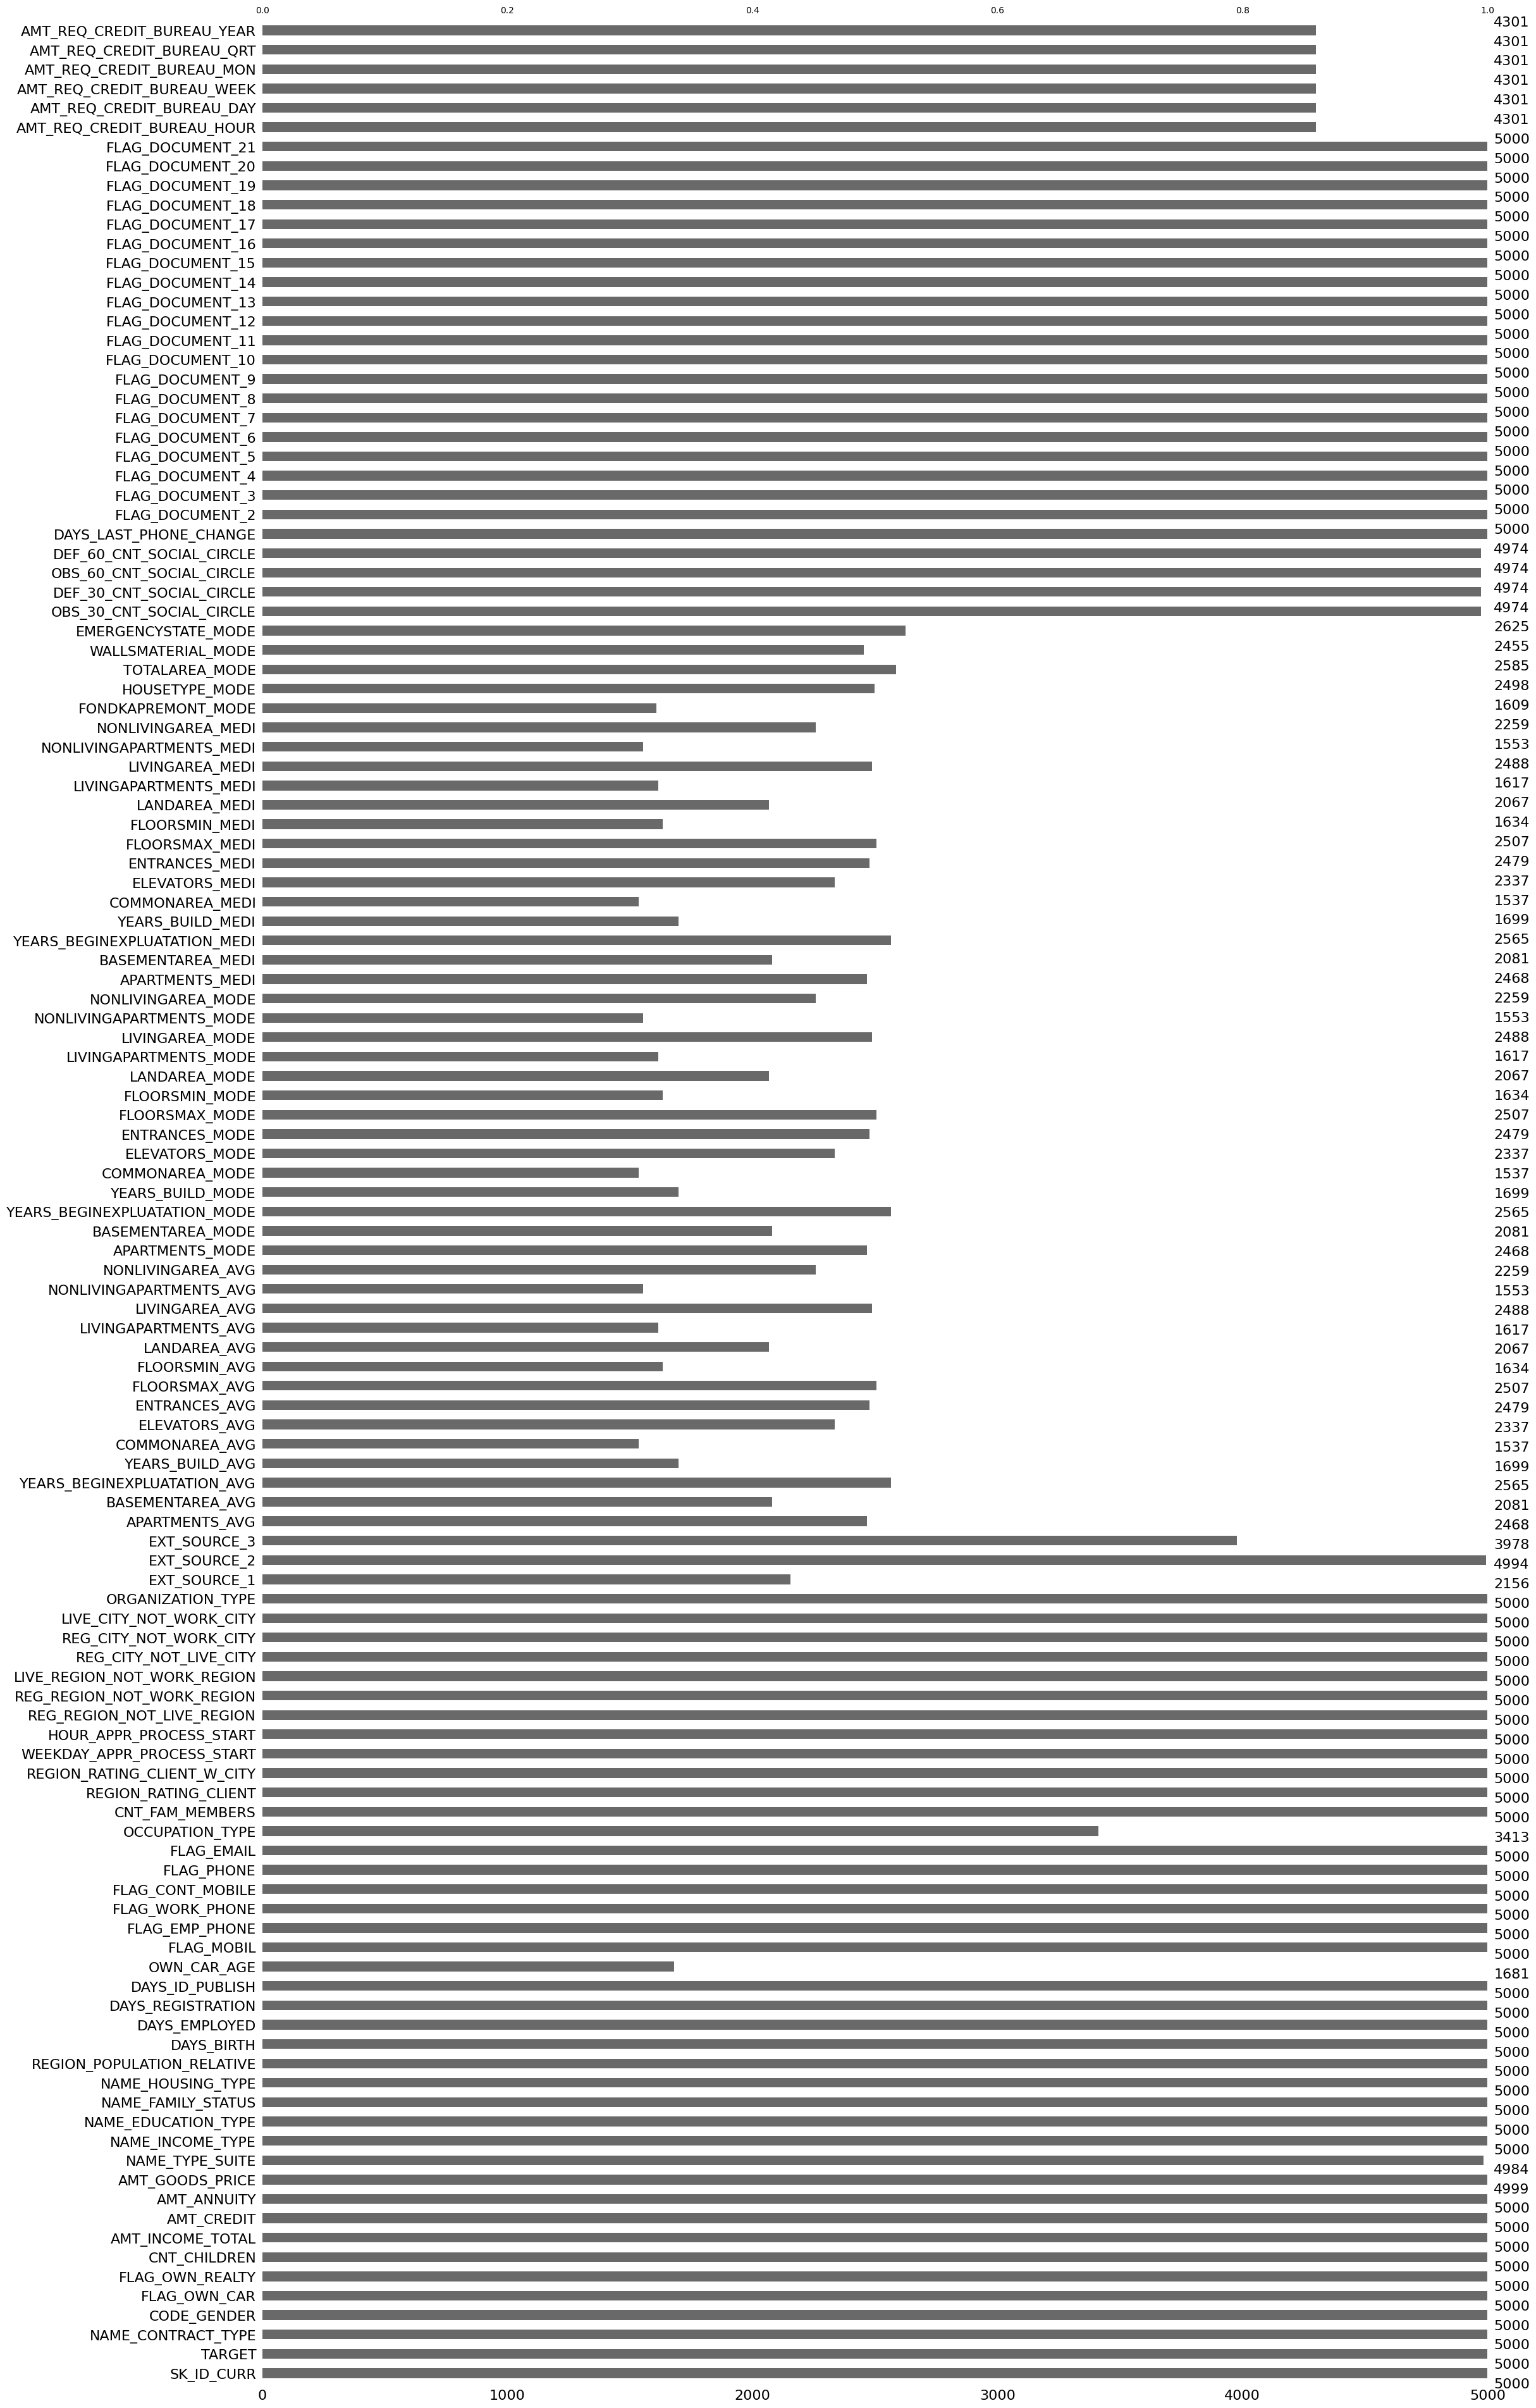

In [4]:
print(app_train["TARGET"].value_counts(normalize=True))

import missingno as msno
msno.bar(app_train.sample(5000))

L'accuracy sera une métrique trompeuse. 
Pour la partie machine learning il faudra au minimum : 
- recall
- AUC
- F1-score

Et on inclura:
- class-weight="balanced"
- StratifierKFold

## Bloc 3 : Feature engineering 

définition CREDIT_INCOME_RATIO = combien de fois le crédit représente le revenu annuel du client
| Ratio | Lecture |
|------|---------|
| < 1  | crédit faible vs revenu (safe) |
| 1–3  | normal |
| 3–5  | risqué |
| > 5  | très risqué |

Le risque de défaut augmente quand:
- l'endettement relatif est élevé
- le client est "over-leveraged"

définition ANNUITY_INCOME_RATIO = part du revenu utilisée pour rembourser chaque année

| Ratio | Lecture |
|------|---------|
| < 0.1 | très confortable |
| 0.1–0.2 | normal |
| 0.2–0.4 | tension financière |
| > 0.5 | stress financier élevé |

Ce ratio approxime:
- capacité de remboursement mensuelle/ annuelle
- pression financière du client

Peut-être souvent plus prédictif que le revenu seul.


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

def base_features(df):
    df = df.copy()

    df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
    df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]

    return df


app_train = base_features(app_train)
app_test = base_features(app_test)

In [6]:
app_train[["CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO"]].describe()

,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO
count,307511.000000,307499.000000
mean,3.957570,0.180930
std,2.689728,0.094574
min,0.004808,0.000224
25%,2.018667,0.114782
50%,3.265067,0.162833
75%,5.159880,0.229067
max,84.736842,1.875965


In [7]:
ratio_cols = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO"
]

import seaborn as sns
import matplotlib.pyplot as plt

def plot_distribution(df, col, dataset_name):
    plt.figure(figsize=(8,5))

    sns.histplot(df[col], bins=50, kde=True)

    plt.title(f"{dataset_name} - Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()


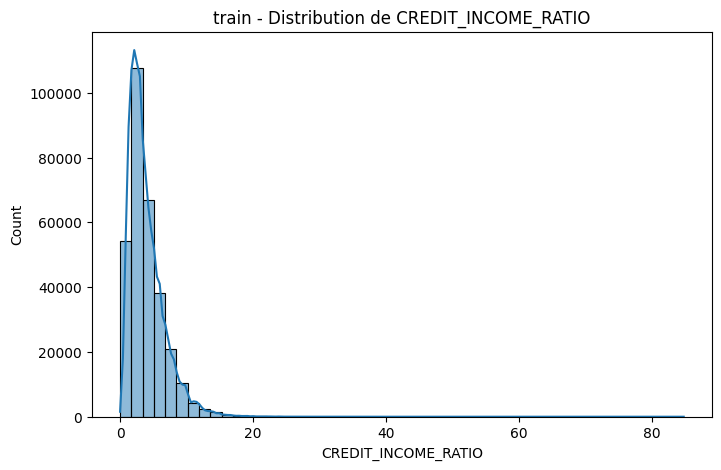

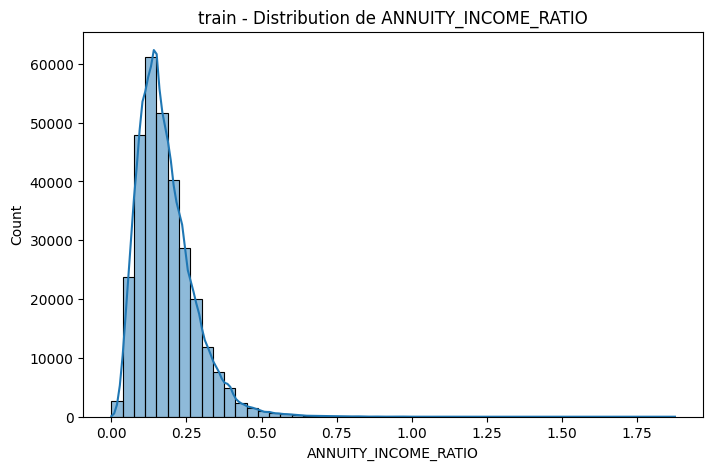

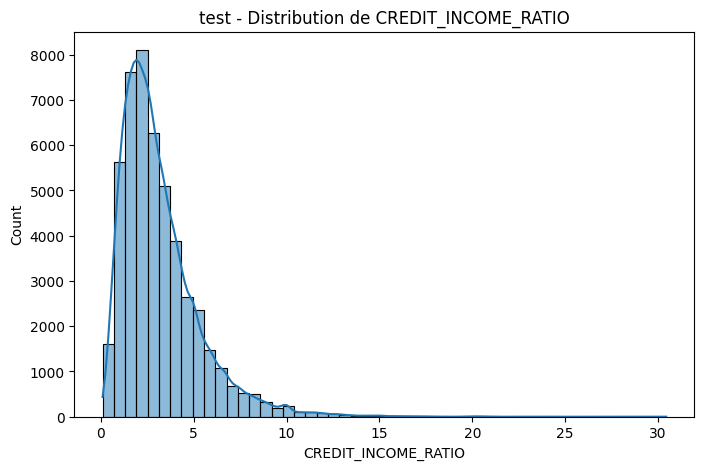

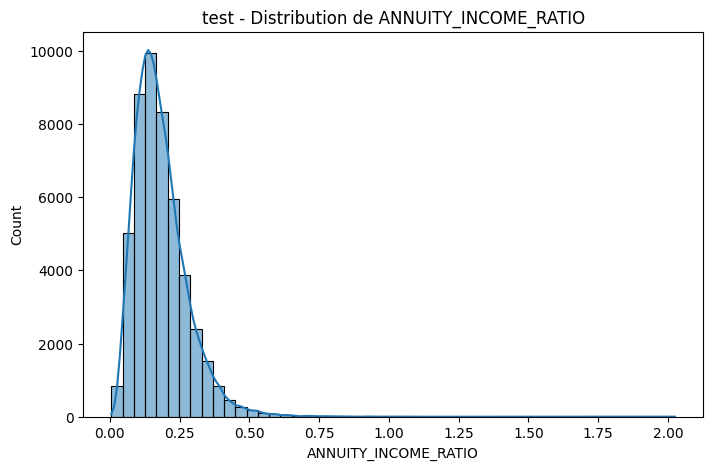

In [8]:
for col in ratio_cols:
    plot_distribution(app_train, col, "train")

for col in ratio_cols:
    plot_distribution(app_test, col, "test")
                    


Analyse de CREDIT_INCOME_RATIO

Standards bancaires pour credit_income_ratio
| Zone | Lecture |
|------|---------|
| 0–2  | solvable confortable |
| 2–5  | standard crédit bancaire |
| >10  | client très risqué |

Distribution très allogée à droite (des clients très risqués tirent la moyenne vers le haut)

Valeur extrême = 84 peut être un possible outlier 

Analyse de ANNUITY_INCOME_RATIO
| Ratio | Interprétation |
|------|----------------|
| < 0.2 | sain |
| 0.2–0.4 | attention |
| > 0.5 | stress financier |
| > 1 | incohérence / très risqué |

Certains clients remboursent plus que leur revenu annuel. Erreur de données ou revenus sous-déclarés probables.





In [9]:
# correction de l'anomalie DAYS_EMPLOYED = 365243
def fix_employment(df):
    df = df.copy()
    
    df["DAYS_EMPLOYED_ANOM"] = df["DAYS_EMPLOYED"] == 365243
    df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)
    
    return df

In [10]:
app_train = fix_employment(app_train)
app_test = fix_employment(app_test)

In [11]:
# Features métiers supplémentaires
# Age client (maturité financière)
app_train["AGE_YEARS"] = app_train["DAYS_BIRTH"] / -365
app_test["AGE_YEARS"] = app_test["DAYS_BIRTH"] / -365

In [12]:
# Employement_years (maturité professionnelle)
app_train["EMPLOYMENT_YEARS"] = app_train["DAYS_EMPLOYED"] / -365
app_test["EMPLOYMENT_YEARS"] = app_test["DAYS_EMPLOYED"] / -365

In [13]:
# Nombre de crédits actifs potentiels (plus la famille est grande plus il y a de pression financière)
app_train["INCOME_PER_PERSON"] = app_train["AMT_INCOME_TOTAL"] / (1 + app_train["CNT_FAM_MEMBERS"])
app_test["INCOME_PER_PERSON"] = app_test["AMT_INCOME_TOTAL"] / (1 + app_test["CNT_FAM_MEMBERS"])

In [14]:
# Contrôle présence valeurs infinies
print("Train")
print(np.isinf(app_train[ratio_cols]).sum())

print("\nTest")
print(np.isinf(app_test[ratio_cols]).sum())

Train
CREDIT_INCOME_RATIO     0
ANNUITY_INCOME_RATIO    0
dtype: int64

Test
CREDIT_INCOME_RATIO     0
ANNUITY_INCOME_RATIO    0
dtype: int64


In [15]:
# Contrôle présence NaN après features
print("Train")
print(app_train[ratio_cols].isnull().sum())

print("\nTest")
print(app_test[ratio_cols].isnull().sum())

Train
CREDIT_INCOME_RATIO      0
ANNUITY_INCOME_RATIO    12
dtype: int64

Test
CREDIT_INCOME_RATIO      0
ANNUITY_INCOME_RATIO    24
dtype: int64


In [16]:
# remplacer les valeurs maquantes par la médiane
app_train["ANNUITY_INCOME_RATIO"] = app_train["ANNUITY_INCOME_RATIO"].fillna(app_train["ANNUITY_INCOME_RATIO"].median())
app_test["ANNUITY_INCOME_RATIO"] = app_test["ANNUITY_INCOME_RATIO"].fillna(app_test["ANNUITY_INCOME_RATIO"].median())

In [17]:
app_train[["CREDIT_INCOME_RATIO","ANNUITY_INCOME_RATIO"]].describe().T

,count,mean,std,min,25%,50%,75%,max
CREDIT_INCOME_RATIO,307511.0,3.957570,2.689728,0.004808,2.018667,3.265067,5.159880,84.736842
ANNUITY_INCOME_RATIO,307511.0,0.180929,0.094572,0.000224,0.114785,0.162833,0.229064,1.875965


In [18]:
app_test[["CREDIT_INCOME_RATIO","ANNUITY_INCOME_RATIO"]].describe().T

,count,mean,std,min,25%,50%,75%,max
CREDIT_INCOME_RATIO,48744.0,3.167544,2.137173,0.09250,1.695695,2.666143,4.0296,30.445000
ANNUITY_INCOME_RATIO,48744.0,0.182975,0.095456,0.00573,0.116397,0.165923,0.2298,2.024714


In [19]:
app_train.shape, app_test.shape

((307511, 128), (48744, 127))

In [20]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 128 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

In [21]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 127 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    NAME_CONTRACT_TYPE            object 
 2    CODE_GENDER                   object 
 3    FLAG_OWN_CAR                  object 
 4    FLAG_OWN_REALTY               object 
 5    CNT_CHILDREN                  int64  
 6    AMT_INCOME_TOTAL              float64
 7    AMT_CREDIT                    float64
 8    AMT_ANNUITY                   float64
 9    AMT_GOODS_PRICE               float64
 10   NAME_TYPE_SUITE               object 
 11   NAME_INCOME_TYPE              object 
 12   NAME_EDUCATION_TYPE           object 
 13   NAME_FAMILY_STATUS            object 
 14   NAME_HOUSING_TYPE             object 
 15   REGION_POPULATION_RELATIVE    float64
 16   DAYS_BIRTH                    int64  
 17   DAYS_EMPLOYED                 float64
 18   DAYS

In [22]:
new_features = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "DAYS_EMPLOYED_ANOM",
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "INCOME_PER_PERSON"
]

app_train[new_features].isnull().sum()

CREDIT_INCOME_RATIO         0
ANNUITY_INCOME_RATIO        0
DAYS_EMPLOYED_ANOM          0
AGE_YEARS                   0
EMPLOYMENT_YEARS        55374
INCOME_PER_PERSON           2
dtype: int64

In [23]:
app_test[new_features].isnull().sum()

CREDIT_INCOME_RATIO        0
ANNUITY_INCOME_RATIO       0
DAYS_EMPLOYED_ANOM         0
AGE_YEARS                  0
EMPLOYMENT_YEARS        9274
INCOME_PER_PERSON          0
dtype: int64

In [24]:
import numpy as np

app_train[new_features].select_dtypes(include=["float64"]).apply(
    lambda col: np.isinf(col).sum()
)

CREDIT_INCOME_RATIO     0
ANNUITY_INCOME_RATIO    0
AGE_YEARS               0
EMPLOYMENT_YEARS        0
INCOME_PER_PERSON       0
dtype: int64

In [25]:
import numpy as np

app_test[new_features].select_dtypes(include=["float64"]).apply(
    lambda col: np.isinf(col).sum()
)

CREDIT_INCOME_RATIO     0
ANNUITY_INCOME_RATIO    0
AGE_YEARS               0
EMPLOYMENT_YEARS        0
INCOME_PER_PERSON       0
dtype: int64

In [26]:
app_train[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
CREDIT_INCOME_RATIO,307511.0,3.957570,2.689728,0.004808,2.018667,3.265067,5.159880,8.473684e+01
ANNUITY_INCOME_RATIO,307511.0,0.180929,0.094572,0.000224,0.114785,0.162833,0.229064,1.875965e+00
AGE_YEARS,307511.0,43.936973,11.956133,20.517808,34.008219,43.150685,53.923288,6.912055e+01
EMPLOYMENT_YEARS,252137.0,6.531971,6.406466,-0.000000,2.101370,4.515068,8.698630,4.907397e+01
INCOME_PER_PERSON,307509.0,57482.254719,65851.657720,2647.058824,33750.000000,49500.000000,67500.000000,2.925000e+07


In [27]:
app_test[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
CREDIT_INCOME_RATIO,48744.0,3.167544,2.137173,0.09250,1.695695,2.666143,4.029600,3.044500e+01
ANNUITY_INCOME_RATIO,48744.0,0.182975,0.095456,0.00573,0.116397,0.165923,0.229800,2.024714e+00
AGE_YEARS,48744.0,44.022150,11.851782,20.10411,34.235616,43.246575,53.800000,6.902740e+01
EMPLOYMENT_YEARS,39470.0,6.785586,6.323189,0.00274,2.358904,4.835616,9.119863,4.784384e+01
INCOME_PER_PERSON,48744.0,60715.182779,38903.141377,4875.00000,37500.000000,52500.000000,75000.000000,2.205000e+06


In [28]:
# Valeurs nulles pour income per person
app_train.loc[
    app_train["INCOME_PER_PERSON"].isna(),
    ["AMT_INCOME_TOTAL", "CNT_FAM_MEMBERS"]
]

,AMT_INCOME_TOTAL,CNT_FAM_MEMBERS
41982,450000.0,NaN
187348,202500.0,NaN


In [29]:
app_train.loc[
    app_train["CNT_FAM_MEMBERS"].isna(),
    [
        "SK_ID_CURR",
        "AMT_INCOME_TOTAL",
        "CNT_FAM_MEMBERS",
        "INCOME_PER_PERSON"
    ]
]

,SK_ID_CURR,AMT_INCOME_TOTAL,CNT_FAM_MEMBERS,INCOME_PER_PERSON
41982,148605,450000.0,NaN,NaN
187348,317181,202500.0,NaN,NaN


In [30]:
median_family = app_train["CNT_FAM_MEMBERS"].median()

print("Médiane CNT_FAM_MEMBERS :", median_family)

Médiane CNT_FAM_MEMBERS : 2.0


In [31]:
app_train["CNT_FAM_MEMBERS"] = (
    app_train["CNT_FAM_MEMBERS"]
    .fillna(median_family)
)

In [32]:
print(
    "Train NaN :",
    app_train["CNT_FAM_MEMBERS"].isna().sum()
)

Train NaN : 0


In [33]:
print(
    "Test NaN :",
    app_test["CNT_FAM_MEMBERS"].isna().sum()
)

Test NaN : 0


In [34]:
app_train["INCOME_PER_PERSON"] = (
    app_train["AMT_INCOME_TOTAL"]
    / app_train["CNT_FAM_MEMBERS"]
)

app_test["INCOME_PER_PERSON"] = (
    app_test["AMT_INCOME_TOTAL"]
    / app_test["CNT_FAM_MEMBERS"]
)

In [35]:
app_train[
    ["AMT_INCOME_TOTAL",
     "CNT_FAM_MEMBERS",
     "INCOME_PER_PERSON"]
].sort_values(
    by="INCOME_PER_PERSON",
    ascending=False
).head(10)

,AMT_INCOME_TOTAL,CNT_FAM_MEMBERS,INCOME_PER_PERSON
12840,117000000.0,3.0,39000000.0
246858,13500000.0,2.0,6750000.0
203693,18000090.0,4.0,4500022.5
77768,9000000.0,2.0,4500000.0
204564,4500000.0,1.0,4500000.0
103006,4500000.0,1.0,4500000.0
284311,3600000.0,1.0,3600000.0
131127,6750000.0,2.0,3375000.0
158338,2250000.0,1.0,2250000.0
206814,2250000.0,1.0,2250000.0


In [36]:
print(
    "Train INCOME_PER_PERSON NaN :",
    app_train["INCOME_PER_PERSON"].isna().sum()
)

print(
    "Test INCOME_PER_PERSON NaN :",
    app_test["INCOME_PER_PERSON"].isna().sum()
)

Train INCOME_PER_PERSON NaN : 0
Test INCOME_PER_PERSON NaN : 0


Deux observations présentaient une valeur manquante pour CNT_FAM_MEMBERS. Une imputation par la médiane calculée sur le jeu d'entraînement a été réalisée afin de conserver les observations. La feature dérivée INCOME_PER_PERSON a ensuite été recalculée. Cette approche évite la suppression de données tout en limitant l'impact sur la distribution de la variable.

In [37]:
# Vérification des clés de jointure
for df_name, df in {
    "train": app_train,
    "test": app_test
}.items():

    print(f"\n{df_name}")

    print("SK_ID_CURR unique :",
          df["SK_ID_CURR"].nunique())

    print("Lignes :",
          len(df))

    print("Doublons :",
          df["SK_ID_CURR"].duplicated().sum())



train
SK_ID_CURR unique : 307511
Lignes : 307511
Doublons : 0

test
SK_ID_CURR unique : 48744
Lignes : 48744
Doublons : 0


In [38]:
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 128 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

In [39]:
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 127 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    NAME_CONTRACT_TYPE            object 
 2    CODE_GENDER                   object 
 3    FLAG_OWN_CAR                  object 
 4    FLAG_OWN_REALTY               object 
 5    CNT_CHILDREN                  int64  
 6    AMT_INCOME_TOTAL              float64
 7    AMT_CREDIT                    float64
 8    AMT_ANNUITY                   float64
 9    AMT_GOODS_PRICE               float64
 10   NAME_TYPE_SUITE               object 
 11   NAME_INCOME_TYPE              object 
 12   NAME_EDUCATION_TYPE           object 
 13   NAME_FAMILY_STATUS            object 
 14   NAME_HOUSING_TYPE             object 
 15   REGION_POPULATION_RELATIVE    float64
 16   DAYS_BIRTH                    int64  
 17   DAYS_EMPLOYED                 float64
 18   DAYS

# Bloc 4 : Aggregations tables secondaires

In [40]:
# tables bureau.csv et bureau_balance.csv
bureau = pd.read_csv(f"{DATA_PATH}/bureau.csv")
bureau_balance = pd.read_csv(f"{DATA_PATH}/bureau_balance.csv")

In [41]:
bureau.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


In [42]:
bureau_balance.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   SK_ID_BUREAU    int64 
 1   MONTHS_BALANCE  int64 
 2   STATUS          object
dtypes: int64(2), object(1)
memory usage: 624.8+ MB


In [43]:
bureau_balance = pd.read_csv(DATA_PATH + "/bureau_balance.csv")

bureau_balance["HAS_LATE"] = bureau_balance["STATUS"].isin(
    ["1", "2", "3", "4", "5"]
).astype(int)

bb_agg = bureau_balance.groupby("SK_ID_BUREAU").agg({
    "MONTHS_BALANCE": ["min", "max", "count"],
    "HAS_LATE": "max"
})

bb_agg.columns = ["_".join(col) for col in bb_agg.columns]
bb_agg = bb_agg.reset_index()

In [44]:
bureau = pd.read_csv(DATA_PATH + "/bureau.csv")

bureau_bb = bureau.merge(
    bb_agg,
    on="SK_ID_BUREAU",
    how="left"
)

In [45]:
bureau_final = bureau_bb.groupby("SK_ID_CURR").agg({
    "DAYS_CREDIT": ["min", "max", "mean"],
    "CREDIT_DAY_OVERDUE": "max",
    "AMT_CREDIT_SUM": "sum",
    "AMT_CREDIT_SUM_DEBT": "sum",
    "MONTHS_BALANCE_count": "mean",
    "MONTHS_BALANCE_min": "min",
    "MONTHS_BALANCE_max": "max",
    "HAS_LATE_max": "max"
})

In [46]:
bureau_final.columns = [
    "_".join(col).replace("__", "_")
    for col in bureau_final.columns
]

bureau_final = bureau_final.reset_index()

In [47]:
print(bureau_final.columns)
print(bureau_final.shape)

Index(['SK_ID_CURR', 'DAYS_CREDIT_min', 'DAYS_CREDIT_max', 'DAYS_CREDIT_mean',
       'CREDIT_DAY_OVERDUE_max', 'AMT_CREDIT_SUM_sum',
       'AMT_CREDIT_SUM_DEBT_sum', 'MONTHS_BALANCE_count_mean',
       'MONTHS_BALANCE_min_min', 'MONTHS_BALANCE_max_max', 'HAS_LATE_max_max'],
      dtype='object')
(305811, 11)


In [48]:
app_train = app_train.merge(bureau_final, on="SK_ID_CURR", how="left")
app_test  = app_test.merge(bureau_final, on="SK_ID_CURR", how="left")

In [49]:
print(app_train.shape)
print(app_test.shape)

(307511, 138)
(48744, 137)


In [50]:
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 138 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

In [51]:
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 137 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    NAME_CONTRACT_TYPE            object 
 2    CODE_GENDER                   object 
 3    FLAG_OWN_CAR                  object 
 4    FLAG_OWN_REALTY               object 
 5    CNT_CHILDREN                  int64  
 6    AMT_INCOME_TOTAL              float64
 7    AMT_CREDIT                    float64
 8    AMT_ANNUITY                   float64
 9    AMT_GOODS_PRICE               float64
 10   NAME_TYPE_SUITE               object 
 11   NAME_INCOME_TYPE              object 
 12   NAME_EDUCATION_TYPE           object 
 13   NAME_FAMILY_STATUS            object 
 14   NAME_HOUSING_TYPE             object 
 15   REGION_POPULATION_RELATIVE    float64
 16   DAYS_BIRTH                    int64  
 17   DAYS_EMPLOYED                 float64
 18   DAYS

In [52]:
app_train.columns.duplicated().sum()

np.int64(0)

In [53]:
app_train["SK_ID_CURR"].isna().sum()

np.int64(0)

In [54]:
app_train.shape

(307511, 138)

In [55]:
app_test.columns.duplicated().sum()

np.int64(0)

In [56]:
app_test["SK_ID_CURR"].isna().sum()

np.int64(0)

In [57]:
app_test.shape

(48744, 137)

In [58]:
# table previous_application.csv
prev = pd.read_csv(f"{DATA_PATH}/previous_application.csv")

In [59]:
prev.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_PREV,1670214.0,1.923089e+06,532597.958696,1.000001e+06,1.461857e+06,1.923110e+06,2.384280e+06,2845382.000
SK_ID_CURR,1670214.0,2.783572e+05,102814.823849,1.000010e+05,1.893290e+05,2.787145e+05,3.675140e+05,456255.000
AMT_ANNUITY,1297979.0,1.595512e+04,14782.137335,0.000000e+00,6.321780e+03,1.125000e+04,2.065842e+04,418058.145
AMT_APPLICATION,1670214.0,1.752339e+05,292779.762386,0.000000e+00,1.872000e+04,7.104600e+04,1.803600e+05,6905160.000
AMT_CREDIT,1670213.0,1.961140e+05,318574.616547,0.000000e+00,2.416050e+04,8.054100e+04,2.164185e+05,6905160.000
AMT_DOWN_PAYMENT,774370.0,6.697402e+03,20921.495410,-9.000000e-01,0.000000e+00,1.638000e+03,7.740000e+03,3060045.000
AMT_GOODS_PRICE,1284699.0,2.278473e+05,315396.557937,0.000000e+00,5.084100e+04,1.123200e+05,2.340000e+05,6905160.000
HOUR_APPR_PROCESS_START,1670214.0,1.248418e+01,3.334028,0.000000e+00,1.000000e+01,1.200000e+01,1.500000e+01,23.000
NFLAG_LAST_APPL_IN_DAY,1670214.0,9.964675e-01,0.059330,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000
RATE_DOWN_PAYMENT,774370.0,7.963682e-02,0.107823,-1.497876e-05,0.000000e+00,5.160508e-02,1.089091e-01,1.000


In [60]:
prev["DAYS_FIRST_DRAWING"] = prev["DAYS_FIRST_DRAWING"].replace(365243, np.nan)
prev["DAYS_FIRST_DUE"] = prev["DAYS_FIRST_DUE"].replace(365243, np.nan)
prev["DAYS_LAST_DUE"] = prev["DAYS_LAST_DUE"].replace(365243, np.nan)
prev["DAYS_TERMINATION"] = prev["DAYS_TERMINATION"].replace(365243, np.nan)

In [61]:
prev["SELLERPLACE_AREA"] = prev["SELLERPLACE_AREA"].clip(upper=10000)

In [62]:
prev["RATE_INTEREST_MEAN"] = prev[
    ["RATE_INTEREST_PRIMARY", "RATE_INTEREST_PRIVILEGED"]
].mean(axis=1)

prev["RATE_INTEREST_IS_MISSING"] = prev[
    "RATE_INTEREST_PRIMARY"
].isna().astype(int)

In [63]:
prev["AMT_DOWN_PAYMENT"] = prev["AMT_DOWN_PAYMENT"].clip(lower=0)

In [64]:
# ratio montant demandé / montant accordé
prev["APP_CREDIT_RATIO"] = prev["AMT_APPLICATION"] / prev["AMT_CREDIT"]

# montant non payé upfront
prev["DOWNPAYMENT_RATIO"] = prev["AMT_DOWN_PAYMENT"] / (prev["AMT_APPLICATION"] + 1)

In [65]:
prev_agg = prev.groupby("SK_ID_CURR").agg({
    "AMT_ANNUITY": ["mean"],
    "AMT_APPLICATION": ["sum", "mean"],
    "AMT_CREDIT": ["sum", "mean"],
    "AMT_DOWN_PAYMENT": ["sum"],
    "CNT_PAYMENT": ["mean"],
    "DAYS_DECISION": ["min", "max", "mean"],
    "APP_CREDIT_RATIO": ["mean"],
    "DOWNPAYMENT_RATIO": ["mean"]
})

In [66]:
prev_agg.columns = [
    "_".join(col).strip() for col in prev_agg.columns
]

prev_agg = prev_agg.reset_index()

In [67]:
print(prev_agg.shape)
print(prev_agg.columns)

(338857, 13)
Index(['SK_ID_CURR', 'AMT_ANNUITY_mean', 'AMT_APPLICATION_sum',
       'AMT_APPLICATION_mean', 'AMT_CREDIT_sum', 'AMT_CREDIT_mean',
       'AMT_DOWN_PAYMENT_sum', 'CNT_PAYMENT_mean', 'DAYS_DECISION_min',
       'DAYS_DECISION_max', 'DAYS_DECISION_mean', 'APP_CREDIT_RATIO_mean',
       'DOWNPAYMENT_RATIO_mean'],
      dtype='object')


In [68]:
app_train = app_train.merge(prev_agg, on="SK_ID_CURR", how="left")
app_test = app_test.merge(prev_agg, on="SK_ID_CURR", how="left")

In [69]:
print(app_train.shape)
print(app_test.shape)

(307511, 150)
(48744, 149)


In [70]:
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 150 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

In [71]:
app_train.columns.duplicated().sum()

np.int64(0)

In [72]:
app_train["SK_ID_CURR"].isna().sum()

np.int64(0)

In [73]:
app_train.describe().T

/mnt/projects/ai_engineer_projects/P06/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,2.781805e+05,1.027902e+05,1.000020e+05,189145.500000,278202.000000,3.671425e+05,4.562550e+05
TARGET,307511.0,8.072882e-02,2.724186e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,1.000000e+00
CNT_CHILDREN,307511.0,4.170517e-01,7.221214e-01,0.000000e+00,0.000000,0.000000,1.000000e+00,1.900000e+01
AMT_INCOME_TOTAL,307511.0,1.687979e+05,2.371231e+05,2.565000e+04,112500.000000,147150.000000,2.025000e+05,1.170000e+08
AMT_CREDIT,307511.0,5.990260e+05,4.024908e+05,4.500000e+04,270000.000000,513531.000000,8.086500e+05,4.050000e+06
AMT_ANNUITY,307499.0,2.710857e+04,1.449374e+04,1.615500e+03,16524.000000,24903.000000,3.459600e+04,2.580255e+05
AMT_GOODS_PRICE,307233.0,5.383962e+05,3.694465e+05,4.050000e+04,238500.000000,450000.000000,6.795000e+05,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,2.086811e-02,1.383128e-02,2.900000e-04,0.010006,0.018850,2.866300e-02,7.250800e-02
DAYS_BIRTH,307511.0,-1.603700e+04,4.363989e+03,-2.522900e+04,-19682.000000,-15750.000000,-1.241300e+04,-7.489000e+03
DAYS_EMPLOYED,252137.0,-2.384169e+03,2.338360e+03,-1.791200e+04,-3175.000000,-1648.000000,-7.670000e+02,0.000000e+00


In [74]:
# Remplacer inf par NaN (très important)
app_train.replace([np.inf, -np.inf], np.nan, inplace=True)
app_train['DAYS_EMPLOYED_ANOM'] = (app_train['DAYS_EMPLOYED'] == 0).astype(int)

app_train['DAYS_EMPLOYED'] = app_train['DAYS_EMPLOYED'].replace(0, np.nan)

for col in ['AMT_INCOME_TOTAL', 'INCOME_PER_PERSON']:
    app_train[col] = app_train[col].clip(
        lower=0,
        upper=app_train[col].quantile(0.999)
    )

app_train['APP_CREDIT_RATIO_mean'] = (
    app_train['AMT_APPLICATION_mean'] / app_train['AMT_CREDIT_mean']
)

app_train.replace([np.inf, -np.inf], np.nan, inplace=True)

def safe_div(a, b):
    return np.where(b == 0, np.nan, a / b)

app_train['CREDIT_INCOME_RATIO'] = safe_div(
    app_train['AMT_CREDIT'],
    app_train['AMT_INCOME_TOTAL']
)



In [75]:
app_train.isna().sum().sort_values(ascending=False).head(20)

MONTHS_BALANCE_max_max       215280
HAS_LATE_max_max             215280
MONTHS_BALANCE_count_mean    215280
MONTHS_BALANCE_min_min       215280
COMMONAREA_MODE              214865
COMMONAREA_AVG               214865
COMMONAREA_MEDI              214865
NONLIVINGAPARTMENTS_MODE     213514
NONLIVINGAPARTMENTS_MEDI     213514
NONLIVINGAPARTMENTS_AVG      213514
FONDKAPREMONT_MODE           210295
LIVINGAPARTMENTS_MEDI        210199
LIVINGAPARTMENTS_MODE        210199
LIVINGAPARTMENTS_AVG         210199
FLOORSMIN_AVG                208642
FLOORSMIN_MEDI               208642
FLOORSMIN_MODE               208642
YEARS_BUILD_MODE             204488
YEARS_BUILD_MEDI             204488
YEARS_BUILD_AVG              204488
dtype: int64

In [76]:
np.isinf(app_train.select_dtypes(include=[np.number])).sum().sum()

np.int64(0)

In [77]:
app_train['AMT_INCOME_TOTAL_LOG'] = np.log1p(app_train['AMT_INCOME_TOTAL'])
app_train['AMT_CREDIT_LOG'] = np.log1p(app_train['AMT_CREDIT'])

In [78]:
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 152 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

In [79]:
app_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,2.781805e+05,1.027902e+05,1.000020e+05,189145.500000,278202.000000,3.671425e+05,4.562550e+05
TARGET,307511.0,8.072882e-02,2.724186e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,1.000000e+00
CNT_CHILDREN,307511.0,4.170517e-01,7.221214e-01,0.000000e+00,0.000000,0.000000,1.000000e+00,1.900000e+01
AMT_INCOME_TOTAL,307511.0,1.677714e+05,9.192889e+04,2.565000e+04,112500.000000,147150.000000,2.025000e+05,9.000000e+05
AMT_CREDIT,307511.0,5.990260e+05,4.024908e+05,4.500000e+04,270000.000000,513531.000000,8.086500e+05,4.050000e+06
AMT_ANNUITY,307499.0,2.710857e+04,1.449374e+04,1.615500e+03,16524.000000,24903.000000,3.459600e+04,2.580255e+05
AMT_GOODS_PRICE,307233.0,5.383962e+05,3.694465e+05,4.050000e+04,238500.000000,450000.000000,6.795000e+05,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,2.086811e-02,1.383128e-02,2.900000e-04,0.010006,0.018850,2.866300e-02,7.250800e-02
DAYS_BIRTH,307511.0,-1.603700e+04,4.363989e+03,-2.522900e+04,-19682.000000,-15750.000000,-1.241300e+04,-7.489000e+03
DAYS_EMPLOYED,252135.0,-2.384188e+03,2.338360e+03,-1.791200e+04,-3175.000000,-1648.000000,-7.670000e+02,-1.000000e+00


In [80]:
app_test.columns.duplicated().sum()

np.int64(0)

In [81]:
app_test["SK_ID_CURR"].isna().sum()

np.int64(0)

In [82]:
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 149 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    NAME_CONTRACT_TYPE            object 
 2    CODE_GENDER                   object 
 3    FLAG_OWN_CAR                  object 
 4    FLAG_OWN_REALTY               object 
 5    CNT_CHILDREN                  int64  
 6    AMT_INCOME_TOTAL              float64
 7    AMT_CREDIT                    float64
 8    AMT_ANNUITY                   float64
 9    AMT_GOODS_PRICE               float64
 10   NAME_TYPE_SUITE               object 
 11   NAME_INCOME_TYPE              object 
 12   NAME_EDUCATION_TYPE           object 
 13   NAME_FAMILY_STATUS            object 
 14   NAME_HOUSING_TYPE             object 
 15   REGION_POPULATION_RELATIVE    float64
 16   DAYS_BIRTH                    int64  
 17   DAYS_EMPLOYED                 float64
 18   DAYS

In [83]:
app_test.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,48744.0,2.777967e+05,1.031695e+05,100001.000000,188557.750000,2.775490e+05,3.675555e+05,4.562500e+05
CNT_CHILDREN,48744.0,3.970540e-01,7.090468e-01,0.000000,0.000000,0.000000e+00,1.000000e+00,2.000000e+01
AMT_INCOME_TOTAL,48744.0,1.784318e+05,1.015226e+05,26941.500000,112500.000000,1.575000e+05,2.250000e+05,4.410000e+06
AMT_CREDIT,48744.0,5.167404e+05,3.653970e+05,45000.000000,260640.000000,4.500000e+05,6.750000e+05,2.245500e+06
AMT_ANNUITY,48720.0,2.942624e+04,1.601637e+04,2295.000000,17973.000000,2.619900e+04,3.739050e+04,1.805760e+05
AMT_GOODS_PRICE,48744.0,4.626188e+05,3.367102e+05,45000.000000,225000.000000,3.960000e+05,6.300000e+05,2.245500e+06
REGION_POPULATION_RELATIVE,48744.0,2.122564e-02,1.442819e-02,0.000253,0.010006,1.885000e-02,2.866300e-02,7.250800e-02
DAYS_BIRTH,48744.0,-1.606808e+04,4.325900e+03,-25195.000000,-19637.000000,-1.578500e+04,-1.249600e+04,-7.338000e+03
DAYS_EMPLOYED,39470.0,-2.476739e+03,2.307964e+03,-17463.000000,-3328.750000,-1.765000e+03,-8.610000e+02,-1.000000e+00
DAYS_REGISTRATION,48744.0,-4.967653e+03,3.552612e+03,-23722.000000,-7459.250000,-4.490000e+03,-1.901000e+03,0.000000e+00


In [84]:
# 1
app_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2
app_test['DAYS_EMPLOYED_ANOM'] = (
    app_test['DAYS_EMPLOYED'] == 0
).astype(int)

app_test['DAYS_EMPLOYED'] = (
    app_test['DAYS_EMPLOYED'].replace(0, np.nan)
)

train_income_cap = app_train['AMT_INCOME_TOTAL'].quantile(0.999)
train_income_pp_cap = app_train['INCOME_PER_PERSON'].quantile(0.999)

# 3 (avec seuils train)
for col, cap in {
    'AMT_INCOME_TOTAL': train_income_cap,
    'INCOME_PER_PERSON': train_income_pp_cap
}.items():
    app_test[col] = app_test[col].clip(
        lower=0,
        upper=cap
    )

# 4
app_test['APP_CREDIT_RATIO_mean'] = safe_div(
    app_test['AMT_APPLICATION_mean'],
    app_test['AMT_CREDIT_mean']
)

# 5
app_test['CREDIT_INCOME_RATIO'] = safe_div(
    app_test['AMT_CREDIT'],
    app_test['AMT_INCOME_TOTAL']
)

# 6
app_test.replace([np.inf, -np.inf], np.nan, inplace=True)

In [85]:
app_test['AMT_INCOME_TOTAL_LOG'] = np.log1p(
    app_test['AMT_INCOME_TOTAL']
)

app_test['AMT_CREDIT_LOG'] = np.log1p(
    app_test['AMT_CREDIT']
)

In [86]:
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 151 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    NAME_CONTRACT_TYPE            object 
 2    CODE_GENDER                   object 
 3    FLAG_OWN_CAR                  object 
 4    FLAG_OWN_REALTY               object 
 5    CNT_CHILDREN                  int64  
 6    AMT_INCOME_TOTAL              float64
 7    AMT_CREDIT                    float64
 8    AMT_ANNUITY                   float64
 9    AMT_GOODS_PRICE               float64
 10   NAME_TYPE_SUITE               object 
 11   NAME_INCOME_TYPE              object 
 12   NAME_EDUCATION_TYPE           object 
 13   NAME_FAMILY_STATUS            object 
 14   NAME_HOUSING_TYPE             object 
 15   REGION_POPULATION_RELATIVE    float64
 16   DAYS_BIRTH                    int64  
 17   DAYS_EMPLOYED                 float64
 18   DAYS

In [87]:
app_test.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,48744.0,2.777967e+05,1.031695e+05,100001.000000,188557.750000,2.775490e+05,3.675555e+05,4.562500e+05
CNT_CHILDREN,48744.0,3.970540e-01,7.090468e-01,0.000000,0.000000,0.000000e+00,1.000000e+00,2.000000e+01
AMT_INCOME_TOTAL,48744.0,1.779298e+05,9.443298e+04,26941.500000,112500.000000,1.575000e+05,2.250000e+05,9.000000e+05
AMT_CREDIT,48744.0,5.167404e+05,3.653970e+05,45000.000000,260640.000000,4.500000e+05,6.750000e+05,2.245500e+06
AMT_ANNUITY,48720.0,2.942624e+04,1.601637e+04,2295.000000,17973.000000,2.619900e+04,3.739050e+04,1.805760e+05
AMT_GOODS_PRICE,48744.0,4.626188e+05,3.367102e+05,45000.000000,225000.000000,3.960000e+05,6.300000e+05,2.245500e+06
REGION_POPULATION_RELATIVE,48744.0,2.122564e-02,1.442819e-02,0.000253,0.010006,1.885000e-02,2.866300e-02,7.250800e-02
DAYS_BIRTH,48744.0,-1.606808e+04,4.325900e+03,-25195.000000,-19637.000000,-1.578500e+04,-1.249600e+04,-7.338000e+03
DAYS_EMPLOYED,39470.0,-2.476739e+03,2.307964e+03,-17463.000000,-3328.750000,-1.765000e+03,-8.610000e+02,-1.000000e+00
DAYS_REGISTRATION,48744.0,-4.967653e+03,3.552612e+03,-23722.000000,-7459.250000,-4.490000e+03,-1.901000e+03,0.000000e+00


In [88]:
(app_test['DAYS_EMPLOYED'] == 365243).sum()
(app_train['DAYS_EMPLOYED'] == 365243).sum()

np.int64(0)

In [89]:
app_test['APP_CREDIT_RATIO_mean'].describe([0.99, 0.995, 0.999])

count    47775.000000
mean         0.943346
std          0.181764
min          0.000000
50%          0.950832
99%          1.428571
99.5%        1.601954
99.9%        2.000000
max         10.000000
Name: APP_CREDIT_RATIO_mean, dtype: float64

In [90]:
app_test.isna().sum().sort_values(ascending=False).head(20)

COMMONAREA_MEDI             33495
COMMONAREA_MODE             33495
COMMONAREA_AVG              33495
NONLIVINGAPARTMENTS_MODE    33347
NONLIVINGAPARTMENTS_AVG     33347
NONLIVINGAPARTMENTS_MEDI    33347
FONDKAPREMONT_MODE          32797
LIVINGAPARTMENTS_AVG        32780
LIVINGAPARTMENTS_MODE       32780
LIVINGAPARTMENTS_MEDI       32780
FLOORSMIN_AVG               32466
FLOORSMIN_MODE              32466
FLOORSMIN_MEDI              32466
OWN_CAR_AGE                 32312
YEARS_BUILD_MEDI            31818
YEARS_BUILD_AVG             31818
YEARS_BUILD_MODE            31818
LANDAREA_MODE               28254
LANDAREA_AVG                28254
LANDAREA_MEDI               28254
dtype: int64

In [91]:
np.isinf(app_test.select_dtypes(include=np.number)).sum().sum()

np.int64(0)

In [92]:
app_train.shape

(307511, 152)

In [93]:
app_test.shape

(48744, 151)

In [94]:
# table pos_cash
pos = pd.read_csv(f"{DATA_PATH}/POS_CASH_balance.csv")

In [95]:
print(pos.shape)

(10001358, 8)


In [96]:
pos.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             int64  
 2   MONTHS_BALANCE         int64  
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   object 
 6   SK_DPD                 int64  
 7   SK_DPD_DEF             int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 610.4+ MB


In [97]:
pos.head()

pos.isna().mean().sort_values(ascending=False).head(10)

CNT_INSTALMENT_FUTURE    0.002608
CNT_INSTALMENT           0.002607
SK_ID_CURR               0.000000
SK_ID_PREV               0.000000
MONTHS_BALANCE           0.000000
NAME_CONTRACT_STATUS     0.000000
SK_DPD                   0.000000
SK_DPD_DEF               0.000000
dtype: float64

In [98]:


# Retards
pos['HAS_LATE'] = (
    (pos['SK_DPD'] > 0) |
    (pos['SK_DPD_DEF'] > 0)
).astype(int)

# Contrat actif
pos['ACTIVE_CONTRACT'] = (
    pos['NAME_CONTRACT_STATUS'] == 'Active'
).astype(int)

# Contrat terminé
pos['COMPLETED_CONTRACT'] = (
    pos['NAME_CONTRACT_STATUS'] == 'Completed'
).astype(int)

In [99]:
pos_agg = pos.groupby('SK_ID_CURR').agg({

    'MONTHS_BALANCE': [
        'min',
        'max',
        'count'
    ],

    'SK_DPD': [
        'max',
        'mean'
    ],

    'SK_DPD_DEF': [
        'max',
        'mean'
    ],

    'CNT_INSTALMENT': [
        'mean',
        'max'
    ],

    'CNT_INSTALMENT_FUTURE': [
        'mean',
        'max'
    ],

    'HAS_LATE': [
        'mean',
        'max'
    ],

    'ACTIVE_CONTRACT': [
        'sum',
        'mean'
    ],

    'COMPLETED_CONTRACT': [
        'sum',
        'mean'
    ]

})

In [100]:
pos_agg.columns = [
    f'POS_{c[0]}_{c[1]}'.upper()
    for c in pos_agg.columns
]

pos_agg.reset_index(inplace=True)

In [101]:
app_train = app_train.merge(
    pos_agg,
    on='SK_ID_CURR',
    how='left'
)

app_test = app_test.merge(
    pos_agg,
    on='SK_ID_CURR',
    how='left'
)

In [102]:
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 169 columns):
 #    Column                          Dtype  
---   ------                          -----  
 0    SK_ID_CURR                      int64  
 1    TARGET                          int64  
 2    NAME_CONTRACT_TYPE              object 
 3    CODE_GENDER                     object 
 4    FLAG_OWN_CAR                    object 
 5    FLAG_OWN_REALTY                 object 
 6    CNT_CHILDREN                    int64  
 7    AMT_INCOME_TOTAL                float64
 8    AMT_CREDIT                      float64
 9    AMT_ANNUITY                     float64
 10   AMT_GOODS_PRICE                 float64
 11   NAME_TYPE_SUITE                 object 
 12   NAME_INCOME_TYPE                object 
 13   NAME_EDUCATION_TYPE             object 
 14   NAME_FAMILY_STATUS              object 
 15   NAME_HOUSING_TYPE               object 
 16   REGION_POPULATION_RELATIVE      float64
 17   DAYS_BIR

In [103]:
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 168 columns):
 #    Column                          Dtype  
---   ------                          -----  
 0    SK_ID_CURR                      int64  
 1    NAME_CONTRACT_TYPE              object 
 2    CODE_GENDER                     object 
 3    FLAG_OWN_CAR                    object 
 4    FLAG_OWN_REALTY                 object 
 5    CNT_CHILDREN                    int64  
 6    AMT_INCOME_TOTAL                float64
 7    AMT_CREDIT                      float64
 8    AMT_ANNUITY                     float64
 9    AMT_GOODS_PRICE                 float64
 10   NAME_TYPE_SUITE                 object 
 11   NAME_INCOME_TYPE                object 
 12   NAME_EDUCATION_TYPE             object 
 13   NAME_FAMILY_STATUS              object 
 14   NAME_HOUSING_TYPE               object 
 15   REGION_POPULATION_RELATIVE      float64
 16   DAYS_BIRTH                      int64  
 17   DAYS_EMPLO

In [104]:
app_train.filter(like='POS_').isna().mean().sort_values(ascending=False)

POS_CNT_INSTALMENT_MEAN           0.058830
POS_CNT_INSTALMENT_FUTURE_MAX     0.058830
POS_CNT_INSTALMENT_MAX            0.058830
POS_CNT_INSTALMENT_FUTURE_MEAN    0.058830
POS_MONTHS_BALANCE_MIN            0.058752
POS_SK_DPD_MEAN                   0.058752
POS_SK_DPD_MAX                    0.058752
POS_MONTHS_BALANCE_MAX            0.058752
POS_MONTHS_BALANCE_COUNT          0.058752
POS_SK_DPD_DEF_MAX                0.058752
POS_SK_DPD_DEF_MEAN               0.058752
POS_HAS_LATE_MEAN                 0.058752
POS_HAS_LATE_MAX                  0.058752
POS_ACTIVE_CONTRACT_SUM           0.058752
POS_ACTIVE_CONTRACT_MEAN          0.058752
POS_COMPLETED_CONTRACT_SUM        0.058752
POS_COMPLETED_CONTRACT_MEAN       0.058752
dtype: float64

In [105]:
app_train['HAS_POS'] = (
    app_train['POS_MONTHS_BALANCE_COUNT']
    .notna()
    .astype(int)
)

app_test['HAS_POS'] = (
    app_test['POS_MONTHS_BALANCE_COUNT']
    .notna()
    .astype(int)
)

In [106]:
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 170 columns):
 #    Column                          Dtype  
---   ------                          -----  
 0    SK_ID_CURR                      int64  
 1    TARGET                          int64  
 2    NAME_CONTRACT_TYPE              object 
 3    CODE_GENDER                     object 
 4    FLAG_OWN_CAR                    object 
 5    FLAG_OWN_REALTY                 object 
 6    CNT_CHILDREN                    int64  
 7    AMT_INCOME_TOTAL                float64
 8    AMT_CREDIT                      float64
 9    AMT_ANNUITY                     float64
 10   AMT_GOODS_PRICE                 float64
 11   NAME_TYPE_SUITE                 object 
 12   NAME_INCOME_TYPE                object 
 13   NAME_EDUCATION_TYPE             object 
 14   NAME_FAMILY_STATUS              object 
 15   NAME_HOUSING_TYPE               object 
 16   REGION_POPULATION_RELATIVE      float64
 17   DAYS_BIR

In [107]:
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 169 columns):
 #    Column                          Dtype  
---   ------                          -----  
 0    SK_ID_CURR                      int64  
 1    NAME_CONTRACT_TYPE              object 
 2    CODE_GENDER                     object 
 3    FLAG_OWN_CAR                    object 
 4    FLAG_OWN_REALTY                 object 
 5    CNT_CHILDREN                    int64  
 6    AMT_INCOME_TOTAL                float64
 7    AMT_CREDIT                      float64
 8    AMT_ANNUITY                     float64
 9    AMT_GOODS_PRICE                 float64
 10   NAME_TYPE_SUITE                 object 
 11   NAME_INCOME_TYPE                object 
 12   NAME_EDUCATION_TYPE             object 
 13   NAME_FAMILY_STATUS              object 
 14   NAME_HOUSING_TYPE               object 
 15   REGION_POPULATION_RELATIVE      float64
 16   DAYS_BIRTH                      int64  
 17   DAYS_EMPLO

In [108]:
np.isinf(app_train.select_dtypes(include=np.number)).sum().sum()

np.int64(0)

In [109]:
np.isinf(app_test.select_dtypes(include=np.number)).sum().sum()

np.int64(0)

In [110]:
print(app_train.shape)
print(app_test.shape)

print(app_train['TARGET'].mean())

(307511, 170)
(48744, 169)
0.08072881945686496


In [111]:
# fichier installments_payments.csv
installments_payments = pd.read_csv(f"{DATA_PATH}/installments_payments.csv")

In [112]:
installments_payments.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB


In [113]:
# Copie de sécurité
inst = installments_payments.copy()

# =========================
# FEATURES DE BASE
# =========================

# Retard de paiement
inst['PAYMENT_DELAY'] = (
    inst['DAYS_ENTRY_PAYMENT'] -
    inst['DAYS_INSTALMENT']
)

# Paiement en avance
inst['PAYMENT_EARLY'] = (
    inst['DAYS_INSTALMENT'] -
    inst['DAYS_ENTRY_PAYMENT']
)

# Montant payé / montant dû
inst['PAYMENT_RATIO'] = np.where(
    inst['AMT_INSTALMENT'] == 0,
    np.nan,
    inst['AMT_PAYMENT'] / inst['AMT_INSTALMENT']
)

# Différence paiement - montant attendu
inst['PAYMENT_DIFF'] = (
    inst['AMT_PAYMENT'] -
    inst['AMT_INSTALMENT']
)

# Indicateurs
inst['LATE_PAYMENT'] = (
    inst['PAYMENT_DELAY'] > 0
).astype(int)

inst['UNDERPAID'] = (
    inst['AMT_PAYMENT'] <
    inst['AMT_INSTALMENT']
).astype(int)

inst['OVERPAID'] = (
    inst['AMT_PAYMENT'] >
    inst['AMT_INSTALMENT']
).astype(int)

# =========================
# AGREGATIONS CLIENT
# =========================

inst_agg = inst.groupby('SK_ID_CURR').agg({

    'NUM_INSTALMENT_VERSION': ['nunique'],

    'PAYMENT_DELAY': [
        'mean',
        'max'
    ],

    'PAYMENT_EARLY': [
        'mean',
        'max'
    ],

    'LATE_PAYMENT': [
        'mean',
        'sum'
    ],

    'UNDERPAID': [
        'mean',
        'sum'
    ],

    'OVERPAID': [
        'mean'
    ],

    'PAYMENT_RATIO': [
        'mean',
        'max'
    ],

    'PAYMENT_DIFF': [
        'mean',
        'sum'
    ],

    'AMT_INSTALMENT': [
        'mean',
        'sum'
    ],

    'AMT_PAYMENT': [
        'mean',
        'sum'
    ],

    'DAYS_INSTALMENT': [
        'min',
        'max'
    ]

})

# Flatten colonnes
inst_agg.columns = [
    'INST_' + '_'.join(col).upper()
    for col in inst_agg.columns
]

inst_agg.reset_index(inplace=True)

print(inst_agg.shape)
inst_agg.head()

(339587, 21)


,SK_ID_CURR,INST_NUM_INSTALMENT_VERSION_NUNIQUE,INST_PAYMENT_DELAY_MEAN,INST_PAYMENT_DELAY_MAX,INST_PAYMENT_EARLY_MEAN,INST_PAYMENT_EARLY_MAX,INST_LATE_PAYMENT_MEAN,INST_LATE_PAYMENT_SUM,INST_UNDERPAID_MEAN,INST_UNDERPAID_SUM,INST_OVERPAID_MEAN,INST_PAYMENT_RATIO_MEAN,INST_PAYMENT_RATIO_MAX,INST_PAYMENT_DIFF_MEAN,INST_PAYMENT_DIFF_SUM,INST_AMT_INSTALMENT_MEAN,INST_AMT_INSTALMENT_SUM,INST_AMT_PAYMENT_MEAN,INST_AMT_PAYMENT_SUM,INST_DAYS_INSTALMENT_MIN,INST_DAYS_INSTALMENT_MAX
0,100001,2,-7.285714,11.0,7.285714,36.0,0.142857,1,0.0,0,0.0,1.0,1.0,0.0,0.0,5885.132143,41195.925,5885.132143,41195.925,-2916.0,-1619.0
1,100002,2,-20.421053,-12.0,20.421053,31.0,0.000000,0,0.0,0,0.0,1.0,1.0,0.0,0.0,11559.247105,219625.695,11559.247105,219625.695,-565.0,-25.0
2,100003,2,-7.160000,-1.0,7.160000,14.0,0.000000,0,0.0,0,0.0,1.0,1.0,0.0,0.0,64754.586000,1618864.650,64754.586000,1618864.650,-2310.0,-536.0
3,100004,2,-7.666667,-3.0,7.666667,11.0,0.000000,0,0.0,0,0.0,1.0,1.0,0.0,0.0,7096.155000,21288.465,7096.155000,21288.465,-784.0,-724.0
4,100005,2,-23.555556,1.0,23.555556,37.0,0.111111,1,0.0,0,0.0,1.0,1.0,0.0,0.0,6240.205000,56161.845,6240.205000,56161.845,-706.0,-466.0


In [114]:
app_train = app_train.merge(
    inst_agg,
    on='SK_ID_CURR',
    how='left'
)

app_test = app_test.merge(
    inst_agg,
    on='SK_ID_CURR',
    how='left'
)

In [115]:
app_train.shape

(307511, 190)

In [116]:
app_test.shape

(48744, 189)

In [117]:
app_train['HAS_INSTALLMENTS'] = (
    app_train['INST_AMT_PAYMENT_SUM']
    .notna()
    .astype(int)
)

app_test['HAS_INSTALLMENTS'] = (
    app_test['INST_AMT_PAYMENT_SUM']
    .notna()
    .astype(int)
)

In [118]:
app_train.shape

(307511, 191)

In [119]:
app_test.shape

(48744, 190)

In [120]:
app_train.replace([np.inf, -np.inf], np.nan, inplace=True)
app_test.replace([np.inf, -np.inf], np.nan, inplace=True)

In [121]:
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 191 columns):
 #    Column                               Dtype  
---   ------                               -----  
 0    SK_ID_CURR                           int64  
 1    TARGET                               int64  
 2    NAME_CONTRACT_TYPE                   object 
 3    CODE_GENDER                          object 
 4    FLAG_OWN_CAR                         object 
 5    FLAG_OWN_REALTY                      object 
 6    CNT_CHILDREN                         int64  
 7    AMT_INCOME_TOTAL                     float64
 8    AMT_CREDIT                           float64
 9    AMT_ANNUITY                          float64
 10   AMT_GOODS_PRICE                      float64
 11   NAME_TYPE_SUITE                      object 
 12   NAME_INCOME_TYPE                     object 
 13   NAME_EDUCATION_TYPE                  object 
 14   NAME_FAMILY_STATUS                   object 
 15   NAME_HOUSING_TY

In [122]:
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 190 columns):
 #    Column                               Dtype  
---   ------                               -----  
 0    SK_ID_CURR                           int64  
 1    NAME_CONTRACT_TYPE                   object 
 2    CODE_GENDER                          object 
 3    FLAG_OWN_CAR                         object 
 4    FLAG_OWN_REALTY                      object 
 5    CNT_CHILDREN                         int64  
 6    AMT_INCOME_TOTAL                     float64
 7    AMT_CREDIT                           float64
 8    AMT_ANNUITY                          float64
 9    AMT_GOODS_PRICE                      float64
 10   NAME_TYPE_SUITE                      object 
 11   NAME_INCOME_TYPE                     object 
 12   NAME_EDUCATION_TYPE                  object 
 13   NAME_FAMILY_STATUS                   object 
 14   NAME_HOUSING_TYPE                    object 
 15   REGION_POPULATION

In [123]:
# credit_card_balance.csv
credit_card_balance = pd.read_csv(f"{DATA_PATH}/credit_card_balance.csv")

In [124]:
credit_card_balance.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  int64  
 2   MONTHS_BALANCE              int64  
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     int64  
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        int64  
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 18  CNT_DRAWINGS_POS_CURRENT    float64
 19  CNT_INSTALMENT_MATURE

In [125]:
cc = credit_card_balance.copy()

# =========================
# FEATURES DE BASE
# =========================

# utilisation crédit
cc['CREDIT_UTILIZATION'] = np.where(
    cc['AMT_CREDIT_LIMIT_ACTUAL'] == 0,
    np.nan,
    cc['AMT_BALANCE'] / cc['AMT_CREDIT_LIMIT_ACTUAL']
)

# paiement vs utilisation
cc['PAYMENT_RATIO'] = np.where(
    cc['AMT_BALANCE'] == 0,
    np.nan,
    cc['AMT_PAYMENT_TOTAL_CURRENT'] / cc['AMT_BALANCE']
)

# tirages totaux
cc['TOTAL_DRAWINGS'] = (
    cc['AMT_DRAWINGS_ATM_CURRENT'] +
    cc['AMT_DRAWINGS_CURRENT'] +
    cc['AMT_DRAWINGS_OTHER_CURRENT'] +
    cc['AMT_DRAWINGS_POS_CURRENT']
)

# comportement de stress
cc['HAS_OVERLIMIT'] = (
    cc['AMT_BALANCE'] > cc['AMT_CREDIT_LIMIT_ACTUAL']
).astype(int)

cc['HAS_DPD'] = (
    cc['SK_DPD'] > 0
).astype(int)

# =========================
# AGGREGATION PAR CLIENT
# =========================

cc_agg = cc.groupby('SK_ID_CURR').agg({

    'AMT_BALANCE': ['mean', 'max'],
    'AMT_CREDIT_LIMIT_ACTUAL': ['mean', 'max'],

    'CREDIT_UTILIZATION': ['mean', 'max'],

    'AMT_PAYMENT_TOTAL_CURRENT': ['mean', 'sum'],

    'TOTAL_DRAWINGS': ['mean', 'sum'],

    'CNT_DRAWINGS_CURRENT': ['mean', 'max'],

    'SK_DPD': ['max', 'mean'],
    'SK_DPD_DEF': ['max', 'mean'],

    'HAS_OVERLIMIT': ['mean', 'sum'],
    'HAS_DPD': ['mean', 'sum']

})

# flatten
cc_agg.columns = [
    'CC_' + '_'.join(col).upper()
    for col in cc_agg.columns
]

cc_agg.reset_index(inplace=True)

print(cc_agg.shape)
cc_agg.head()

(103558, 21)


,SK_ID_CURR,CC_AMT_BALANCE_MEAN,CC_AMT_BALANCE_MAX,CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN,CC_AMT_CREDIT_LIMIT_ACTUAL_MAX,CC_CREDIT_UTILIZATION_MEAN,CC_CREDIT_UTILIZATION_MAX,CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN,CC_AMT_PAYMENT_TOTAL_CURRENT_SUM,CC_TOTAL_DRAWINGS_MEAN,CC_TOTAL_DRAWINGS_SUM,CC_CNT_DRAWINGS_CURRENT_MEAN,CC_CNT_DRAWINGS_CURRENT_MAX,CC_SK_DPD_MAX,CC_SK_DPD_MEAN,CC_SK_DPD_DEF_MAX,CC_SK_DPD_DEF_MEAN,CC_HAS_OVERLIMIT_MEAN,CC_HAS_OVERLIMIT_SUM,CC_HAS_DPD_MEAN,CC_HAS_DPD_SUM
0,100006,0.000000,0.00,270000.000000,270000,0.000000,0.00000,0.000000,0.000,NaN,0.0,0.000000,0,0,0.000000,0,0.000000,0.000000,0,0.000000,0
1,100011,54482.111149,189000.00,164189.189189,180000,0.302678,1.05000,4520.067568,334485.000,4864.864865,360000.0,0.054054,4,0,0.000000,0,0.000000,0.040541,3,0.000000,0
2,100013,18159.919219,161420.22,131718.750000,157500,0.115301,1.02489,6817.172344,654448.545,12700.000000,1143000.0,0.239583,7,1,0.010417,1,0.010417,0.010417,1,0.010417,1
3,100021,0.000000,0.00,675000.000000,675000,0.000000,0.00000,0.000000,0.000,NaN,0.0,0.000000,0,0,0.000000,0,0.000000,0.000000,0,0.000000,0
4,100023,0.000000,0.00,135000.000000,225000,0.000000,0.00000,0.000000,0.000,NaN,0.0,0.000000,0,0,0.000000,0,0.000000,0.000000,0,0.000000,0


In [126]:
cc_agg.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103558 entries, 0 to 103557
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   SK_ID_CURR                         103558 non-null  int64  
 1   CC_AMT_BALANCE_MEAN                103558 non-null  float64
 2   CC_AMT_BALANCE_MAX                 103558 non-null  float64
 3   CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN    103558 non-null  float64
 4   CC_AMT_CREDIT_LIMIT_ACTUAL_MAX     103558 non-null  int64  
 5   CC_CREDIT_UTILIZATION_MEAN         102445 non-null  float64
 6   CC_CREDIT_UTILIZATION_MAX          102445 non-null  float64
 7   CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN  103558 non-null  float64
 8   CC_AMT_PAYMENT_TOTAL_CURRENT_SUM   103558 non-null  float64
 9   CC_TOTAL_DRAWINGS_MEAN             72194 non-null   float64
 10  CC_TOTAL_DRAWINGS_SUM              103558 non-null  float64
 11  CC_CNT_DRAWINGS_CURRENT_MEAN       1035

In [127]:
app_train = app_train.merge(cc_agg, on='SK_ID_CURR', how='left')
app_test = app_test.merge(cc_agg, on='SK_ID_CURR', how='left')

In [128]:
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 211 columns):
 #    Column                               Dtype  
---   ------                               -----  
 0    SK_ID_CURR                           int64  
 1    TARGET                               int64  
 2    NAME_CONTRACT_TYPE                   object 
 3    CODE_GENDER                          object 
 4    FLAG_OWN_CAR                         object 
 5    FLAG_OWN_REALTY                      object 
 6    CNT_CHILDREN                         int64  
 7    AMT_INCOME_TOTAL                     float64
 8    AMT_CREDIT                           float64
 9    AMT_ANNUITY                          float64
 10   AMT_GOODS_PRICE                      float64
 11   NAME_TYPE_SUITE                      object 
 12   NAME_INCOME_TYPE                     object 
 13   NAME_EDUCATION_TYPE                  object 
 14   NAME_FAMILY_STATUS                   object 
 15   NAME_HOUSING_TY

In [129]:
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 210 columns):
 #    Column                               Dtype  
---   ------                               -----  
 0    SK_ID_CURR                           int64  
 1    NAME_CONTRACT_TYPE                   object 
 2    CODE_GENDER                          object 
 3    FLAG_OWN_CAR                         object 
 4    FLAG_OWN_REALTY                      object 
 5    CNT_CHILDREN                         int64  
 6    AMT_INCOME_TOTAL                     float64
 7    AMT_CREDIT                           float64
 8    AMT_ANNUITY                          float64
 9    AMT_GOODS_PRICE                      float64
 10   NAME_TYPE_SUITE                      object 
 11   NAME_INCOME_TYPE                     object 
 12   NAME_EDUCATION_TYPE                  object 
 13   NAME_FAMILY_STATUS                   object 
 14   NAME_HOUSING_TYPE                    object 
 15   REGION_POPULATION

In [130]:
app_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,2.781805e+05,1.027902e+05,1.000020e+05,189145.500000,278202.000000,3.671425e+05,4.562550e+05
TARGET,307511.0,8.072882e-02,2.724186e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,1.000000e+00
CNT_CHILDREN,307511.0,4.170517e-01,7.221214e-01,0.000000e+00,0.000000,0.000000,1.000000e+00,1.900000e+01
AMT_INCOME_TOTAL,307511.0,1.677714e+05,9.192889e+04,2.565000e+04,112500.000000,147150.000000,2.025000e+05,9.000000e+05
AMT_CREDIT,307511.0,5.990260e+05,4.024908e+05,4.500000e+04,270000.000000,513531.000000,8.086500e+05,4.050000e+06
AMT_ANNUITY,307499.0,2.710857e+04,1.449374e+04,1.615500e+03,16524.000000,24903.000000,3.459600e+04,2.580255e+05
AMT_GOODS_PRICE,307233.0,5.383962e+05,3.694465e+05,4.050000e+04,238500.000000,450000.000000,6.795000e+05,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,2.086811e-02,1.383128e-02,2.900000e-04,0.010006,0.018850,2.866300e-02,7.250800e-02
DAYS_BIRTH,307511.0,-1.603700e+04,4.363989e+03,-2.522900e+04,-19682.000000,-15750.000000,-1.241300e+04,-7.489000e+03
DAYS_EMPLOYED,252135.0,-2.384188e+03,2.338360e+03,-1.791200e+04,-3175.000000,-1648.000000,-7.670000e+02,-1.000000e+00


In [131]:
app_train.columns[app_train.columns.duplicated()]
na_ratio = app_train.isna().mean().sort_values(ascending=False)
na_ratio.head(30)

CC_TOTAL_DRAWINGS_MEAN               0.801178
CC_CREDIT_UTILIZATION_MEAN           0.720218
CC_CREDIT_UTILIZATION_MAX            0.720218
CC_AMT_CREDIT_LIMIT_ACTUAL_MAX       0.717392
CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN      0.717392
CC_AMT_BALANCE_MAX                   0.717392
CC_HAS_OVERLIMIT_MEAN                0.717392
CC_AMT_PAYMENT_TOTAL_CURRENT_SUM     0.717392
CC_SK_DPD_MEAN                       0.717392
CC_SK_DPD_DEF_MAX                    0.717392
CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN    0.717392
CC_HAS_DPD_SUM                       0.717392
CC_TOTAL_DRAWINGS_SUM                0.717392
CC_CNT_DRAWINGS_CURRENT_MEAN         0.717392
CC_SK_DPD_DEF_MEAN                   0.717392
CC_CNT_DRAWINGS_CURRENT_MAX          0.717392
CC_HAS_DPD_MEAN                      0.717392
CC_HAS_OVERLIMIT_SUM                 0.717392
CC_SK_DPD_MAX                        0.717392
CC_AMT_BALANCE_MEAN                  0.717392
MONTHS_BALANCE_max_max               0.700073
HAS_LATE_max_max                  

In [132]:
app_train.shape

(307511, 211)

In [133]:
app_test.shape

(48744, 210)

In [134]:
app_train.shape[1] == app_test.shape[1] - 1  # TARGET en plus dans train

False

In [135]:
set(app_train.columns) - set(app_test.columns)

{'TARGET'}

In [136]:
important_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

app_train[important_cols].isna().sum()

AMT_INCOME_TOTAL         0
AMT_CREDIT               0
AMT_ANNUITY             12
EXT_SOURCE_1        173378
EXT_SOURCE_2           660
EXT_SOURCE_3         60965
dtype: int64

In [137]:
train_cols = set(app_train.columns)
test_cols = set(app_test.columns)

only_in_train = train_cols - test_cols
only_in_test = test_cols - train_cols

only_in_train, only_in_test

({'TARGET'}, set())

In [138]:
app_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,2.781805e+05,1.027902e+05,1.000020e+05,189145.500000,278202.000000,3.671425e+05,4.562550e+05
TARGET,307511.0,8.072882e-02,2.724186e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,1.000000e+00
CNT_CHILDREN,307511.0,4.170517e-01,7.221214e-01,0.000000e+00,0.000000,0.000000,1.000000e+00,1.900000e+01
AMT_INCOME_TOTAL,307511.0,1.677714e+05,9.192889e+04,2.565000e+04,112500.000000,147150.000000,2.025000e+05,9.000000e+05
AMT_CREDIT,307511.0,5.990260e+05,4.024908e+05,4.500000e+04,270000.000000,513531.000000,8.086500e+05,4.050000e+06
AMT_ANNUITY,307499.0,2.710857e+04,1.449374e+04,1.615500e+03,16524.000000,24903.000000,3.459600e+04,2.580255e+05
AMT_GOODS_PRICE,307233.0,5.383962e+05,3.694465e+05,4.050000e+04,238500.000000,450000.000000,6.795000e+05,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,2.086811e-02,1.383128e-02,2.900000e-04,0.010006,0.018850,2.866300e-02,7.250800e-02
DAYS_BIRTH,307511.0,-1.603700e+04,4.363989e+03,-2.522900e+04,-19682.000000,-15750.000000,-1.241300e+04,-7.489000e+03
DAYS_EMPLOYED,252135.0,-2.384188e+03,2.338360e+03,-1.791200e+04,-3175.000000,-1648.000000,-7.670000e+02,-1.000000e+00


In [139]:
app_test.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,48744.0,2.777967e+05,1.031695e+05,1.000010e+05,188557.750000,2.775490e+05,3.675555e+05,4.562500e+05
CNT_CHILDREN,48744.0,3.970540e-01,7.090468e-01,0.000000e+00,0.000000,0.000000e+00,1.000000e+00,2.000000e+01
AMT_INCOME_TOTAL,48744.0,1.779298e+05,9.443298e+04,2.694150e+04,112500.000000,1.575000e+05,2.250000e+05,9.000000e+05
AMT_CREDIT,48744.0,5.167404e+05,3.653970e+05,4.500000e+04,260640.000000,4.500000e+05,6.750000e+05,2.245500e+06
AMT_ANNUITY,48720.0,2.942624e+04,1.601637e+04,2.295000e+03,17973.000000,2.619900e+04,3.739050e+04,1.805760e+05
AMT_GOODS_PRICE,48744.0,4.626188e+05,3.367102e+05,4.500000e+04,225000.000000,3.960000e+05,6.300000e+05,2.245500e+06
REGION_POPULATION_RELATIVE,48744.0,2.122564e-02,1.442819e-02,2.530000e-04,0.010006,1.885000e-02,2.866300e-02,7.250800e-02
DAYS_BIRTH,48744.0,-1.606808e+04,4.325900e+03,-2.519500e+04,-19637.000000,-1.578500e+04,-1.249600e+04,-7.338000e+03
DAYS_EMPLOYED,39470.0,-2.476739e+03,2.307964e+03,-1.746300e+04,-3328.750000,-1.765000e+03,-8.610000e+02,-1.000000e+00
DAYS_REGISTRATION,48744.0,-4.967653e+03,3.552612e+03,-2.372200e+04,-7459.250000,-4.490000e+03,-1.901000e+03,0.000000e+00


In [140]:
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 211 columns):
 #    Column                               Dtype  
---   ------                               -----  
 0    SK_ID_CURR                           int64  
 1    TARGET                               int64  
 2    NAME_CONTRACT_TYPE                   object 
 3    CODE_GENDER                          object 
 4    FLAG_OWN_CAR                         object 
 5    FLAG_OWN_REALTY                      object 
 6    CNT_CHILDREN                         int64  
 7    AMT_INCOME_TOTAL                     float64
 8    AMT_CREDIT                           float64
 9    AMT_ANNUITY                          float64
 10   AMT_GOODS_PRICE                      float64
 11   NAME_TYPE_SUITE                      object 
 12   NAME_INCOME_TYPE                     object 
 13   NAME_EDUCATION_TYPE                  object 
 14   NAME_FAMILY_STATUS                   object 
 15   NAME_HOUSING_TY

In [141]:
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 210 columns):
 #    Column                               Dtype  
---   ------                               -----  
 0    SK_ID_CURR                           int64  
 1    NAME_CONTRACT_TYPE                   object 
 2    CODE_GENDER                          object 
 3    FLAG_OWN_CAR                         object 
 4    FLAG_OWN_REALTY                      object 
 5    CNT_CHILDREN                         int64  
 6    AMT_INCOME_TOTAL                     float64
 7    AMT_CREDIT                           float64
 8    AMT_ANNUITY                          float64
 9    AMT_GOODS_PRICE                      float64
 10   NAME_TYPE_SUITE                      object 
 11   NAME_INCOME_TYPE                     object 
 12   NAME_EDUCATION_TYPE                  object 
 13   NAME_FAMILY_STATUS                   object 
 14   NAME_HOUSING_TYPE                    object 
 15   REGION_POPULATION

In [142]:
num_cols = app_train.select_dtypes(include=['int64','float64']).columns

num_cols = num_cols.drop('TARGET', errors='ignore')

cat_cols = app_train.select_dtypes(include=['object']).columns

In [143]:
# NUMERIC
app_train[num_cols] = app_train[num_cols].fillna(app_train[num_cols].median())
app_test[num_cols] = app_test[num_cols].fillna(app_train[num_cols].median())

# CATEGORICAL
app_train[cat_cols] = app_train[cat_cols].fillna("Missing")
app_test[cat_cols] = app_test[cat_cols].fillna("Missing")

In [144]:
app_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,2.781805e+05,1.027902e+05,1.000020e+05,189145.500000,278202.000000,3.671425e+05,4.562550e+05
TARGET,307511.0,8.072882e-02,2.724186e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,1.000000e+00
CNT_CHILDREN,307511.0,4.170517e-01,7.221214e-01,0.000000e+00,0.000000,0.000000,1.000000e+00,1.900000e+01
AMT_INCOME_TOTAL,307511.0,1.677714e+05,9.192889e+04,2.565000e+04,112500.000000,147150.000000,2.025000e+05,9.000000e+05
AMT_CREDIT,307511.0,5.990260e+05,4.024908e+05,4.500000e+04,270000.000000,513531.000000,8.086500e+05,4.050000e+06
AMT_ANNUITY,307511.0,2.710849e+04,1.449346e+04,1.615500e+03,16524.000000,24903.000000,3.459600e+04,2.580255e+05
AMT_GOODS_PRICE,307511.0,5.383163e+05,3.692890e+05,4.050000e+04,238500.000000,450000.000000,6.795000e+05,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,2.086811e-02,1.383128e-02,2.900000e-04,0.010006,0.018850,2.866300e-02,7.250800e-02
DAYS_BIRTH,307511.0,-1.603700e+04,4.363989e+03,-2.522900e+04,-19682.000000,-15750.000000,-1.241300e+04,-7.489000e+03
DAYS_EMPLOYED,307511.0,-2.251617e+03,2.136186e+03,-1.791200e+04,-2760.000000,-1648.000000,-9.330000e+02,-1.000000e+00


In [145]:
app_test.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,48744.0,2.777967e+05,1.031695e+05,1.000010e+05,188557.750000,277549.000000,3.675555e+05,4.562500e+05
CNT_CHILDREN,48744.0,3.970540e-01,7.090468e-01,0.000000e+00,0.000000,0.000000,1.000000e+00,2.000000e+01
AMT_INCOME_TOTAL,48744.0,1.779298e+05,9.443298e+04,2.694150e+04,112500.000000,157500.000000,2.250000e+05,9.000000e+05
AMT_CREDIT,48744.0,5.167404e+05,3.653970e+05,4.500000e+04,260640.000000,450000.000000,6.750000e+05,2.245500e+06
AMT_ANNUITY,48744.0,2.942401e+04,1.601274e+04,2.295000e+03,17973.000000,26194.500000,3.739050e+04,1.805760e+05
AMT_GOODS_PRICE,48744.0,4.626188e+05,3.367102e+05,4.500000e+04,225000.000000,396000.000000,6.300000e+05,2.245500e+06
REGION_POPULATION_RELATIVE,48744.0,2.122564e-02,1.442819e-02,2.530000e-04,0.010006,0.018850,2.866300e-02,7.250800e-02
DAYS_BIRTH,48744.0,-1.606808e+04,4.325900e+03,-2.519500e+04,-19637.000000,-15785.000000,-1.249600e+04,-7.338000e+03
DAYS_EMPLOYED,48744.0,-2.319064e+03,2.102150e+03,-1.746300e+04,-2910.000000,-1648.000000,-1.048000e+03,-1.000000e+00
DAYS_REGISTRATION,48744.0,-4.967653e+03,3.552612e+03,-2.372200e+04,-7459.250000,-4490.000000,-1.901000e+03,0.000000e+00


Etapes restantes pour finir notebook 1 EDA
- Audit des 16 variables catégorielles.
- Imputation mode des catégorielles.
- Imputation médiane des numériques.
- Suppression variance quasi nulle.
- Corrélations > 0.95.
- Sauvegarde app_train_clean.parquet et app_test_clean.parquet.
- Encodage catégoriel.
- Création finale de X et y.
- Sauvegarde app_train_ml.parquet et app_test_ml.parquet.
- Passage au Notebook 2 (MLflow : Logistic Regression, Random Forest, XGBoost, LightGBM, CatBoost).

In [146]:
# Analyse variables catégorielles 
cat_cols = app_train.select_dtypes(include="object").columns.tolist()
cat_cols

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [147]:
cat_cols = app_test.select_dtypes(include="object").columns.tolist()
cat_cols

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [148]:
# Recherche nombre valeurs nulles
null_cat = app_train[cat_cols].isnull().sum().sort_values(ascending=False)

display(null_cat)

NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
FLAG_OWN_REALTY               0
NAME_TYPE_SUITE               0
NAME_INCOME_TYPE              0
NAME_EDUCATION_TYPE           0
NAME_FAMILY_STATUS            0
NAME_HOUSING_TYPE             0
OCCUPATION_TYPE               0
WEEKDAY_APPR_PROCESS_START    0
ORGANIZATION_TYPE             0
FONDKAPREMONT_MODE            0
HOUSETYPE_MODE                0
WALLSMATERIAL_MODE            0
EMERGENCYSTATE_MODE           0
dtype: int64

In [149]:
app_test[cat_cols].isnull().sum()

NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
FLAG_OWN_REALTY               0
NAME_TYPE_SUITE               0
NAME_INCOME_TYPE              0
NAME_EDUCATION_TYPE           0
NAME_FAMILY_STATUS            0
NAME_HOUSING_TYPE             0
OCCUPATION_TYPE               0
WEEKDAY_APPR_PROCESS_START    0
ORGANIZATION_TYPE             0
FONDKAPREMONT_MODE            0
HOUSETYPE_MODE                0
WALLSMATERIAL_MODE            0
EMERGENCYSTATE_MODE           0
dtype: int64

In [150]:
# Afficher les modalités des variables catégorielles 
for col in cat_cols:
    print(f"\n{col}")
    print(app_train[col].value_counts(dropna=False))


NAME_CONTRACT_TYPE
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

CODE_GENDER
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

FLAG_OWN_CAR
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64

FLAG_OWN_REALTY
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64

NAME_TYPE_SUITE
NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Missing              1292
Other_A               866
Group of people       271
Name: count, dtype: int64

NAME_INCOME_TYPE
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

NAME_EDUCATION_TYPE
NAME_EDUCATION_TYPE
Secondary / s

In [151]:
# Afficher les modalités des variables catégorielles
for col in cat_cols:

    nb_manquants = app_train[col].isna().sum()
    pct_manquants = app_train[col].isna().mean() * 100
    nb_modalites = app_train[col].nunique(dropna=True)

    print(f"\n{'='*50}")
    print(f"Variable : {col}")
    print(f"Nombre de modalités : {nb_modalites}")
    print(f"Valeurs manquantes : {nb_manquants} ({pct_manquants:.2f}%)")
    print("-"*50)

    freq = app_train[col].value_counts(dropna=False)
    pct = app_train[col].value_counts(dropna=False, normalize=True) * 100

    result = pd.DataFrame({
        'Effectif': freq,
        'Pourcentage (%)': pct.round(2)
    })

    print(result)


Variable : NAME_CONTRACT_TYPE
Nombre de modalités : 2
Valeurs manquantes : 0 (0.00%)
--------------------------------------------------
                    Effectif  Pourcentage (%)
NAME_CONTRACT_TYPE                           
Cash loans            278232            90.48
Revolving loans        29279             9.52

Variable : CODE_GENDER
Nombre de modalités : 3
Valeurs manquantes : 0 (0.00%)
--------------------------------------------------
             Effectif  Pourcentage (%)
CODE_GENDER                           
F              202448            65.83
M              105059            34.16
XNA                 4             0.00

Variable : FLAG_OWN_CAR
Nombre de modalités : 2
Valeurs manquantes : 0 (0.00%)
--------------------------------------------------
              Effectif  Pourcentage (%)
FLAG_OWN_CAR                           
N               202924            65.99
Y               104587            34.01

Variable : FLAG_OWN_REALTY
Nombre de modalités : 2
Valeurs man

In [152]:
for col in cat_cols:
    print(f"\n{col}")
    print(app_test[col].value_counts(dropna=False))


NAME_CONTRACT_TYPE
NAME_CONTRACT_TYPE
Cash loans         48305
Revolving loans      439
Name: count, dtype: int64

CODE_GENDER
CODE_GENDER
F    32678
M    16066
Name: count, dtype: int64

FLAG_OWN_CAR
FLAG_OWN_CAR
N    32311
Y    16433
Name: count, dtype: int64

FLAG_OWN_REALTY
FLAG_OWN_REALTY
Y    33658
N    15086
Name: count, dtype: int64

NAME_TYPE_SUITE
NAME_TYPE_SUITE
Unaccompanied      39727
Family              5881
Spouse, partner     1448
Missing              911
Children             408
Other_B              211
Other_A              109
Group of people       49
Name: count, dtype: int64

NAME_INCOME_TYPE
NAME_INCOME_TYPE
Working                 24533
Commercial associate    11402
Pensioner                9273
State servant            3532
Student                     2
Businessman                 1
Unemployed                  1
Name: count, dtype: int64

NAME_EDUCATION_TYPE
NAME_EDUCATION_TYPE
Secondary / secondary special    33988
Higher education                 12516
Incompl

In [153]:
# Afficher les modalités des variables catégorielles
for col in cat_cols:

    nb_manquants = app_test[col].isna().sum()
    pct_manquants = app_test[col].isna().mean() * 100
    nb_modalites = app_test[col].nunique(dropna=True)

    print(f"\n{'='*50}")
    print(f"Variable : {col}")
    print(f"Nombre de modalités : {nb_modalites}")
    print(f"Valeurs manquantes : {nb_manquants} ({pct_manquants:.2f}%)")
    print("-"*50)

    freq = app_test[col].value_counts(dropna=False)
    pct = app_test[col].value_counts(dropna=False, normalize=True) * 100

    result = pd.DataFrame({
        'Effectif': freq,
        'Pourcentage (%)': pct.round(2)
    })

    print(result)


Variable : NAME_CONTRACT_TYPE
Nombre de modalités : 2
Valeurs manquantes : 0 (0.00%)
--------------------------------------------------
                    Effectif  Pourcentage (%)
NAME_CONTRACT_TYPE                           
Cash loans             48305             99.1
Revolving loans          439              0.9

Variable : CODE_GENDER
Nombre de modalités : 2
Valeurs manquantes : 0 (0.00%)
--------------------------------------------------
             Effectif  Pourcentage (%)
CODE_GENDER                           
F               32678            67.04
M               16066            32.96

Variable : FLAG_OWN_CAR
Nombre de modalités : 2
Valeurs manquantes : 0 (0.00%)
--------------------------------------------------
              Effectif  Pourcentage (%)
FLAG_OWN_CAR                           
N                32311            66.29
Y                16433            33.71

Variable : FLAG_OWN_REALTY
Nombre de modalités : 2
Valeurs manquantes : 0 (0.00%)
-------------------

Pas de valeurs manquantes sur les variables catégorielles de app_train et app_test

In [154]:
# Recherche de valeurs manquantes sur les variables numériques 
num_cols = app_train.select_dtypes(
    include=["int64","float64"]
).columns

na_num = app_train[num_cols].isnull().sum().sort_values(ascending=False)

display(na_num.head(50))

SK_ID_CURR                      0
TARGET                          0
CNT_CHILDREN                    0
AMT_INCOME_TOTAL                0
AMT_CREDIT                      0
AMT_ANNUITY                     0
AMT_GOODS_PRICE                 0
REGION_POPULATION_RELATIVE      0
DAYS_BIRTH                      0
DAYS_EMPLOYED                   0
DAYS_REGISTRATION               0
DAYS_ID_PUBLISH                 0
OWN_CAR_AGE                     0
FLAG_MOBIL                      0
FLAG_EMP_PHONE                  0
FLAG_WORK_PHONE                 0
FLAG_CONT_MOBILE                0
FLAG_PHONE                      0
FLAG_EMAIL                      0
CNT_FAM_MEMBERS                 0
REGION_RATING_CLIENT            0
REGION_RATING_CLIENT_W_CITY     0
HOUR_APPR_PROCESS_START         0
REG_REGION_NOT_LIVE_REGION      0
REG_REGION_NOT_WORK_REGION      0
LIVE_REGION_NOT_WORK_REGION     0
REG_CITY_NOT_LIVE_CITY          0
REG_CITY_NOT_WORK_CITY          0
LIVE_CITY_NOT_WORK_CITY         0
EXT_SOURCE_1  

In [155]:
# Recherche de valeurs manquantes sur les variables numériques

num_cols = app_train.select_dtypes(
    include=["int64", "float64"]
).columns

print(f"Nombre total de colonnes numériques : {len(num_cols)}")

na_count = app_train[num_cols].isnull().sum()
na_pct = (app_train[num_cols].isnull().mean() * 100).round(2)

na_num = (
    pd.DataFrame({
        "Colonne": na_count.index,
        "Nb_manquants": na_count.values,
        "%_manquants": na_pct.values
    })
    .sort_values("Nb_manquants", ascending=False)
    .reset_index(drop=True)
)

# Ajout d'un compteur
na_num.index = na_num.index + 1
na_num.index.name = "N°"

display(na_num)

Nombre total de colonnes numériques : 195


,Colonne,Nb_manquants,%_manquants
N°,,,
1,SK_ID_CURR,0,0.0
2,TARGET,0,0.0
3,CNT_CHILDREN,0,0.0
4,AMT_INCOME_TOTAL,0,0.0
5,AMT_CREDIT,0,0.0
6,AMT_ANNUITY,0,0.0
7,AMT_GOODS_PRICE,0,0.0
8,REGION_POPULATION_RELATIVE,0,0.0
9,DAYS_BIRTH,0,0.0


In [156]:
# Recherche de valeurs manquantes sur les variables numériques
num_cols = app_test.select_dtypes(
    include=["int64","float64"]
).columns

na_num = app_test[num_cols].isnull().sum().sort_values(ascending=False)

display(na_num.head(50))

SK_ID_CURR                      0
CNT_CHILDREN                    0
AMT_INCOME_TOTAL                0
AMT_CREDIT                      0
AMT_ANNUITY                     0
AMT_GOODS_PRICE                 0
REGION_POPULATION_RELATIVE      0
DAYS_BIRTH                      0
DAYS_EMPLOYED                   0
DAYS_REGISTRATION               0
DAYS_ID_PUBLISH                 0
OWN_CAR_AGE                     0
FLAG_MOBIL                      0
FLAG_EMP_PHONE                  0
FLAG_WORK_PHONE                 0
FLAG_CONT_MOBILE                0
FLAG_PHONE                      0
FLAG_EMAIL                      0
CNT_FAM_MEMBERS                 0
REGION_RATING_CLIENT            0
REGION_RATING_CLIENT_W_CITY     0
HOUR_APPR_PROCESS_START         0
REG_REGION_NOT_LIVE_REGION      0
REG_REGION_NOT_WORK_REGION      0
LIVE_REGION_NOT_WORK_REGION     0
REG_CITY_NOT_LIVE_CITY          0
REG_CITY_NOT_WORK_CITY          0
LIVE_CITY_NOT_WORK_CITY         0
EXT_SOURCE_1                    0
EXT_SOURCE_2  

In [157]:
# Recherche de valeurs manquantes sur les variables numériques
num_cols = app_test.select_dtypes(
    include=["int64", "float64"]
).columns

print(f"Nombre total de colonnes numériques : {len(num_cols)}")

na_count = app_test[num_cols].isnull().sum()
na_pct = (app_test[num_cols].isnull().mean() * 100).round(2)

na_num = (
    pd.DataFrame({
        "Colonne": na_count.index,
        "Nb_manquants": na_count.values,
        "%_manquants": na_pct.values
    })
    .sort_values("Nb_manquants", ascending=False)
    .reset_index(drop=True)
)

# Ajout d'un compteur
na_num.index = na_num.index + 1
na_num.index.name = "N°"

display(na_num)

Nombre total de colonnes numériques : 194


,Colonne,Nb_manquants,%_manquants
N°,,,
1,SK_ID_CURR,0,0.0
2,CNT_CHILDREN,0,0.0
3,AMT_INCOME_TOTAL,0,0.0
4,AMT_CREDIT,0,0.0
5,AMT_ANNUITY,0,0.0
6,AMT_GOODS_PRICE,0,0.0
7,REGION_POPULATION_RELATIVE,0,0.0
8,DAYS_BIRTH,0,0.0
9,DAYS_EMPLOYED,0,0.0


In [158]:
# Nouveau contrôle du nombre de lignes et de colonnes
print("app_train :", app_train.shape)
print("app_test  :", app_test.shape)

app_train : (307511, 211)
app_test  : (48744, 210)


In [159]:
# Recherche de colonnes numériques avec variance quasi nulle
from sklearn.feature_selection import VarianceThreshold

X_num_train = app_train.drop(columns=["TARGET"])

selector = VarianceThreshold(threshold=0)

selector.fit(
    X_num_train.select_dtypes(exclude="object")
)

low_var_cols_train = (
    X_num_train
    .select_dtypes(exclude="object")
    .columns[~selector.get_support()]
)

print(low_var_cols_train)



Index([], dtype='object')


pas de colonnes à variance nulle sur app_train donc on ne supprime aucune colonnes sur app_test ni sur app_train

In [160]:
# recherche de corrélations linéaires fortes entre colonnes
corr = (
    app_train
    .select_dtypes(exclude="object")
    .drop(columns=["TARGET"])
    .corr(method="spearman")
    .abs()
)

In [161]:
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95)
]

In [162]:
len(to_drop)

46

In [163]:
sorted(to_drop)

['AGE_YEARS',
 'AMT_CREDIT_LOG',
 'AMT_CREDIT_sum',
 'AMT_GOODS_PRICE',
 'AMT_INCOME_TOTAL_LOG',
 'APARTMENTS_MEDI',
 'BASEMENTAREA_MEDI',
 'CC_HAS_DPD_MEAN',
 'CC_HAS_DPD_SUM',
 'CC_HAS_OVERLIMIT_SUM',
 'CC_SK_DPD_DEF_MEAN',
 'CC_SK_DPD_MEAN',
 'COMMONAREA_MEDI',
 'ELEVATORS_MEDI',
 'ELEVATORS_MODE',
 'EMPLOYMENT_YEARS',
 'ENTRANCES_MEDI',
 'ENTRANCES_MODE',
 'FLOORSMAX_MEDI',
 'FLOORSMAX_MODE',
 'FLOORSMIN_MEDI',
 'FLOORSMIN_MODE',
 'INST_AMT_PAYMENT_MEAN',
 'INST_AMT_PAYMENT_SUM',
 'INST_PAYMENT_DIFF_MEAN',
 'INST_PAYMENT_DIFF_SUM',
 'INST_PAYMENT_EARLY_MEAN',
 'INST_PAYMENT_RATIO_MAX',
 'INST_UNDERPAID_SUM',
 'LANDAREA_MEDI',
 'LIVINGAPARTMENTS_MEDI',
 'LIVINGAREA_MEDI',
 'NONLIVINGAPARTMENTS_MEDI',
 'NONLIVINGAREA_MEDI',
 'OBS_60_CNT_SOCIAL_CIRCLE',
 'POS_ACTIVE_CONTRACT_SUM',
 'POS_CNT_INSTALMENT_FUTURE_MAX',
 'POS_HAS_LATE_MAX',
 'POS_HAS_LATE_MEAN',
 'POS_SK_DPD_DEF_MEAN',
 'POS_SK_DPD_MEAN',
 'REGION_RATING_CLIENT_W_CITY',
 'YEARS_BEGINEXPLUATATION_MEDI',
 'YEARS_BEGINEXPLUATA

In [164]:
corr_pairs = []

for col in upper.columns:
    high_corr = upper[col][upper[col] > 0.95]

    for idx, value in high_corr.items():
        corr_pairs.append((idx, col, value))

corr_pairs = sorted(
    corr_pairs,
    key=lambda x: x[2],
    reverse=True
)

corr_pairs[:30]

[('DAYS_BIRTH', 'AGE_YEARS', 1.0),
 ('AMT_INCOME_TOTAL', 'AMT_INCOME_TOTAL_LOG', 1.0),
 ('AMT_CREDIT', 'AMT_CREDIT_LOG', 1.0),
 ('INST_PAYMENT_DELAY_MEAN', 'INST_PAYMENT_EARLY_MEAN', 1.0),
 ('DAYS_EMPLOYED', 'EMPLOYMENT_YEARS', 0.9999901835256716),
 ('CC_SK_DPD_MAX', 'CC_SK_DPD_MEAN', 0.9998130553906682),
 ('CC_SK_DPD_MEAN', 'CC_HAS_DPD_MEAN', 0.9997975581925832),
 ('CC_HAS_DPD_MEAN', 'CC_HAS_DPD_SUM', 0.999786661269143),
 ('CC_SK_DPD_DEF_MAX', 'CC_SK_DPD_DEF_MEAN', 0.9997394047833517),
 ('CC_SK_DPD_MAX', 'CC_HAS_DPD_MEAN', 0.9994297194517316),
 ('CC_SK_DPD_MEAN', 'CC_HAS_DPD_SUM', 0.9994285115224166),
 ('CC_SK_DPD_MAX', 'CC_HAS_DPD_SUM', 0.9991473774450214),
 ('POS_SK_DPD_DEF_MAX', 'POS_SK_DPD_DEF_MEAN', 0.9987653095727054),
 ('POS_SK_DPD_MAX', 'POS_SK_DPD_MEAN', 0.9980700577408745),
 ('CC_HAS_OVERLIMIT_MEAN', 'CC_HAS_OVERLIMIT_SUM', 0.9977856235931261),
 ('OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 0.9973379468684095),
 ('POS_SK_DPD_MEAN', 'POS_HAS_LATE_MEAN', 0.997082720

In [165]:
# colonnes à supprimer
cols_to_drop = [
    # doublons log / original
    'DAYS_BIRTH',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',

    # AVG / MODE redondants
    'YEARS_BUILD_AVG',
    'YEARS_BUILD_MODE',
    'YEARS_BEGINEXPLUATATION_AVG',
    'YEARS_BEGINEXPLUATATION_MODE',
    'FLOORSMAX_AVG',
    'FLOORSMIN_AVG',
    'LANDAREA_AVG',

    # SUM redondants
    'INST_AMT_PAYMENT_SUM',
    'INST_AMT_INSTALMENT_SUM',
    'INST_PAYMENT_DIFF_SUM',
    'CC_HAS_OVERLIMIT_SUM',
    'CC_HAS_DPD_SUM',

    # OBS duplicates
    'OBS_30_CNT_SOCIAL_CIRCLE',

    # POS redondants
    'POS_ACTIVE_CONTRACT_SUM',
    'POS_CNT_INSTALMENT_FUTURE_MAX'
]

In [166]:
# éviter erreurs si colonnes absentes 
cols_to_drop = [col for col in cols_to_drop if col in app_train.columns]

In [167]:
# suppression cohérente app_train et app_test
app_train_clean = app_train.drop(columns=cols_to_drop)
app_test_clean  = app_test.drop(columns=cols_to_drop)

In [168]:
# contrôle des shape avant et après 
print("Shape app_train avant :", app_train.shape)
print("Shape app_train après :", app_train_clean.shape)

print("Shape app_test avant :", app_test.shape)
print("Shape app_test après :", app_test_clean.shape)

Shape app_train avant : (307511, 211)
Shape app_train après : (307511, 193)
Shape app_test avant : (48744, 210)
Shape app_test après : (48744, 192)


In [169]:
# Vérification cohérence des colonnes entre train et test 
print("Colonnes identiques train/test ?",
      set(app_train_clean.drop(columns=['TARGET']).columns) ==
      set(app_test_clean.columns))

Colonnes identiques train/test ? True


In [170]:
# Test fu Khi2 sur les variables catégorielles 
from scipy.stats import chi2_contingency

cat_cols = app_train.select_dtypes(include="object").columns

for col in cat_cols:

    contingency = pd.crosstab(
        app_train[col],
        app_train["TARGET"]
    )

    chi2, p, dof, expected = chi2_contingency(contingency)

    print(col, p)

NAME_CONTRACT_TYPE 1.0235150721172847e-65
CODE_GENDER 1.1290217848908289e-200
FLAG_OWN_CAR 9.330994431109667e-34
FLAG_OWN_REALTY 0.0006681470317545887
NAME_TYPE_SUITE 1.2562030207008644e-07
NAME_INCOME_TYPE 1.9281456056861122e-266
NAME_EDUCATION_TYPE 2.4476812052198174e-219
NAME_FAMILY_STATUS 7.744841561414037e-107
NAME_HOUSING_TYPE 1.0990890032617707e-88
OCCUPATION_TYPE 0.0
WEEKDAY_APPR_PROCESS_START 0.01744736931389504
ORGANIZATION_TYPE 5.224541090300172e-299
FONDKAPREMONT_MODE 9.504317433236526e-60
HOUSETYPE_MODE 4.3693096011918614e-110
WALLSMATERIAL_MODE 3.9168421872326693e-125
EMERGENCYSTATE_MODE 1.0198212313643335e-119


p < 0.05 sur toutes les variables catégorielles donc variables associées à target à conserver

In [171]:
app_train_clean.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 193 columns):
 #    Column                               Dtype  
---   ------                               -----  
 0    SK_ID_CURR                           int64  
 1    TARGET                               int64  
 2    NAME_CONTRACT_TYPE                   object 
 3    CODE_GENDER                          object 
 4    FLAG_OWN_CAR                         object 
 5    FLAG_OWN_REALTY                      object 
 6    CNT_CHILDREN                         int64  
 7    AMT_ANNUITY                          float64
 8    AMT_GOODS_PRICE                      float64
 9    NAME_TYPE_SUITE                      object 
 10   NAME_INCOME_TYPE                     object 
 11   NAME_EDUCATION_TYPE                  object 
 12   NAME_FAMILY_STATUS                   object 
 13   NAME_HOUSING_TYPE                    object 
 14   REGION_POPULATION_RELATIVE           float64
 15   DAYS_EMPLOYED  

In [172]:
app_test_clean.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 192 columns):
 #    Column                               Dtype  
---   ------                               -----  
 0    SK_ID_CURR                           int64  
 1    NAME_CONTRACT_TYPE                   object 
 2    CODE_GENDER                          object 
 3    FLAG_OWN_CAR                         object 
 4    FLAG_OWN_REALTY                      object 
 5    CNT_CHILDREN                         int64  
 6    AMT_ANNUITY                          float64
 7    AMT_GOODS_PRICE                      float64
 8    NAME_TYPE_SUITE                      object 
 9    NAME_INCOME_TYPE                     object 
 10   NAME_EDUCATION_TYPE                  object 
 11   NAME_FAMILY_STATUS                   object 
 12   NAME_HOUSING_TYPE                    object 
 13   REGION_POPULATION_RELATIVE           float64
 14   DAYS_EMPLOYED                        float64
 15   DAYS_REGISTRATION

In [173]:
# Sauvegarde de app_train_clean et app_test_clean au format parquet avant encodage des variables catégorielles
app_train_clean.to_parquet(
    "app_train_clean.parquet",
    index=False
)

app_test_clean.to_parquet(
    "app_test_clean.parquet",
    index=False
)


In [174]:
# Encodage des variables catégorielles 
# Affichage des colonnes catégorielles (object)

cat_cols = app_train_clean.select_dtypes(include="object").columns.tolist()

print("Colonnes catégorielles (object) :")
print(cat_cols)
print("\nNombre total :", len(cat_cols))

Colonnes catégorielles (object) :
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

Nombre total : 16


In [175]:
# Séparer cardinalités hautes et basses

high_card_cols = [
    col for col in cat_cols
    if app_train_clean[col].nunique() > 20
]

low_card_cols = [
    col for col in cat_cols
    if app_train_clean[col].nunique() <= 20
]

print("\nHigh cardinality (>20) :", high_card_cols)
print("Low cardinality (<=20) :", low_card_cols)


High cardinality (>20) : ['ORGANIZATION_TYPE']
Low cardinality (<=20) : ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [176]:
# Frequency encoding pour les cardinalités hautes

for col in high_card_cols:
    freq = app_train_clean[col].value_counts(normalize=True)

    app_train_clean[col] = app_train_clean[col].map(freq)
    app_test_clean[col] = app_test_clean[col].map(freq)

    # gestion des catégories inconnues dans test
    app_train_clean[col] = app_train_clean[col].fillna(0)
    app_test_clean[col] = app_test_clean[col].fillna(0)

In [177]:
# One-Hot Encoding pour les cardinalités faibles

app_train_clean = pd.get_dummies(app_train_clean, columns=low_card_cols, drop_first=True)
app_test_clean = pd.get_dummies(app_test_clean, columns=low_card_cols, drop_first=True)

In [178]:
# Vérification alignement colonnes app_train_clean et app_test_clean 

app_train_clean, app_test_clean = app_train_clean.align(
    app_test_clean,
    join="left",
    axis=1,
    fill_value=0
)

In [179]:
# Vérification finale 

print("\nShape train :", app_train_clean.shape)
print("Shape test  :", app_test_clean.shape)




Shape train : (307511, 251)
Shape test  : (48744, 251)


In [180]:
app_train_clean.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 251 columns):
 #    Column                                             Dtype  
---   ------                                             -----  
 0    SK_ID_CURR                                         int64  
 1    TARGET                                             int64  
 2    CNT_CHILDREN                                       int64  
 3    AMT_ANNUITY                                        float64
 4    AMT_GOODS_PRICE                                    float64
 5    REGION_POPULATION_RELATIVE                         float64
 6    DAYS_EMPLOYED                                      float64
 7    DAYS_REGISTRATION                                  float64
 8    DAYS_ID_PUBLISH                                    int64  
 9    OWN_CAR_AGE                                        float64
 10   FLAG_MOBIL                                         int64  
 11   FLAG_EMP_PHONE                       

In [181]:
app_test_clean.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 251 columns):
 #    Column                                             Dtype  
---   ------                                             -----  
 0    SK_ID_CURR                                         int64  
 1    TARGET                                             int64  
 2    CNT_CHILDREN                                       int64  
 3    AMT_ANNUITY                                        float64
 4    AMT_GOODS_PRICE                                    float64
 5    REGION_POPULATION_RELATIVE                         float64
 6    DAYS_EMPLOYED                                      float64
 7    DAYS_REGISTRATION                                  float64
 8    DAYS_ID_PUBLISH                                    int64  
 9    OWN_CAR_AGE                                        float64
 10   FLAG_MOBIL                                         int64  
 11   FLAG_EMP_PHONE                         

In [182]:
train_cols = set(app_train_clean.drop(columns=["TARGET"]).columns)
test_cols = set(app_test_clean.columns)

print("Colonnes dans train mais pas test :")
print(train_cols - test_cols)

print("\nColonnes dans test mais pas train :")
print(test_cols - train_cols)

Colonnes dans train mais pas test :
set()

Colonnes dans test mais pas train :
{'TARGET'}


In [183]:
# suppression colonne Target de app_test_clean
app_test_clean = app_test_clean.drop(columns=["TARGET"], errors="ignore")

In [184]:
app_train_clean.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 251 columns):
 #    Column                                             Dtype  
---   ------                                             -----  
 0    SK_ID_CURR                                         int64  
 1    TARGET                                             int64  
 2    CNT_CHILDREN                                       int64  
 3    AMT_ANNUITY                                        float64
 4    AMT_GOODS_PRICE                                    float64
 5    REGION_POPULATION_RELATIVE                         float64
 6    DAYS_EMPLOYED                                      float64
 7    DAYS_REGISTRATION                                  float64
 8    DAYS_ID_PUBLISH                                    int64  
 9    OWN_CAR_AGE                                        float64
 10   FLAG_MOBIL                                         int64  
 11   FLAG_EMP_PHONE                       

In [185]:
app_test_clean.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 250 columns):
 #    Column                                             Dtype  
---   ------                                             -----  
 0    SK_ID_CURR                                         int64  
 1    CNT_CHILDREN                                       int64  
 2    AMT_ANNUITY                                        float64
 3    AMT_GOODS_PRICE                                    float64
 4    REGION_POPULATION_RELATIVE                         float64
 5    DAYS_EMPLOYED                                      float64
 6    DAYS_REGISTRATION                                  float64
 7    DAYS_ID_PUBLISH                                    int64  
 8    OWN_CAR_AGE                                        float64
 9    FLAG_MOBIL                                         int64  
 10   FLAG_EMP_PHONE                                     int64  
 11   FLAG_WORK_PHONE                        

In [186]:
# construction de X_train, y_train, X_test en vérifiant que tout est numérique
# Séparer target
y_train = app_train_clean["TARGET"]
X_train = app_train_clean.drop(columns=["TARGET"])

X_test = app_test_clean.copy()

# Harmoniser types 
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

# Convertir bool en int
bool_cols = X_train.select_dtypes(include="bool").columns
X_train[bool_cols] = X_train[bool_cols].astype("int8")
X_test[bool_cols] = X_test[bool_cols].astype("int8")

# contrôle final
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print(X_train.shape, X_test.shape)
print(X_train.dtypes.value_counts())

(307511, 250) (48744, 250)
float64    136
int8        73
int64       41
Name: count, dtype: int64


In [187]:
"TARGET" in X_test.columns  

False

In [188]:
print("=== SHAPES ===")
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")

print("\n=== COLONNES X_train ===")
print(X_train.columns.tolist())

print("\n=== COLONNES X_test ===")
print(X_test.columns.tolist())

=== SHAPES ===
X_train: (307511, 250)
X_test : (48744, 250)
y_train: (307511,)

=== COLONNES X_train ===
['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MOD

In [189]:
# dernières vérificaitons avant passage notebook 2 pour expérimentations MLflow
y_train.value_counts(normalize=True)


TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

In [190]:
(X_train.nunique() <= 1).sum()

np.int64(0)

In [191]:
X_train.isna().sum().sum(), X_test.isna().sum().sum()

(np.int64(0), np.int64(0))

In [192]:
print("=== SHAPES ===")
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")

print("\n=== COLONNES X_train ===")
print(X_train.columns.tolist())

print("\n=== COLONNES X_test ===")
print(X_test.columns.tolist())

# Vérification des valeurs nulles
print("\n=== VALEURS NULLES ===")
print(f"X_train : {X_train.isnull().sum().sum()} valeur(s) nulle(s)")
print(f"X_test  : {X_test.isnull().sum().sum()} valeur(s) nulle(s)")
print(f"y_train : {y_train.isnull().sum()} valeur(s) nulle(s)")

# Vérification des lignes dupliquées
print("\n=== DOUBLONS (LIGNES) ===")
print(f"X_train : {X_train.duplicated().sum()} doublon(s)")
print(f"X_test  : {X_test.duplicated().sum()} doublon(s)")

# Vérification des doublons dans y_train
print("\n=== DOUBLONS DANS y_train ===")
print(f"Valeurs dupliquées : {y_train.duplicated().sum()}")

=== SHAPES ===
X_train: (307511, 250)
X_test : (48744, 250)
y_train: (307511,)

=== COLONNES X_train ===
['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MOD

In [193]:
# Sauvegarde dataset final
X_train.to_parquet("X_train_ml.parquet", index=False)
X_test.to_parquet("X_test_ml.parquet", index=False)
y_train.to_frame().to_parquet("y_train_ml.parquet", index=False)